In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import CubicSpline
from datetime import timedelta
from math import radians, cos, sin, asin, sqrt
import warnings

warnings.filterwarnings("ignore")

# Setup paths
data_dir = Path("../processed_data")
output_dir = Path("../outputs_preprocessing")
output_dir.mkdir(exist_ok=True)

print(f"Data directory: {data_dir.absolute()}")
print(f"Output directory: {output_dir.absolute()}")

Data directory: f:\PyTorch_GPU\maritime_monitoring_preprocessing\Loitering\..\processed_data
Output directory: f:\PyTorch_GPU\maritime_monitoring_preprocessing\Loitering\..\outputs_preprocessing


In [2]:
# ==================== COMPREHENSIVE TRAJECTORY REDUNDANCY FORMULAS ====================
# Implementing all detection methods from the research paper


def haversine(lat1, lon1, lat2, lon2):
    """Calculate distance in nautical miles between two points."""
    R = 3440.065  # Earth's radius in nautical miles
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))
    return R * c


def calculate_course(lat1, lon1, lat2, lon2):
    """Calculate Course Over Ground (COG) in degrees (0-360)."""
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = sin(dlon) * cos(lat2)
    y = cos(lat1) * sin(lat2) - sin(lat1) * cos(lat2) * cos(dlon)
    cog = (np.arctan2(x, y) * 180 / np.pi) % 360
    return cog


def calculate_course_change(cog_curr, cog_prev):
    """
    Calculate course change (Algorithm 1 from paper).
    Normalizes to [0, 180] degrees.
    """
    if cog_prev is None or np.isnan(cog_prev) or np.isnan(cog_curr):
        return 0.0

    delta_c = abs(cog_curr - cog_prev)

    if delta_c > 180:
        return 360 - delta_c
    return delta_c


def calculate_speed(lat1, lon1, lat2, lon2, time_delta_seconds):
    """
    Calculate speed in knots.

    Parameters:
    -----------
    lat1, lon1, lat2, lon2 : float
        Coordinates of two consecutive points
    time_delta_seconds : float
        Time difference in seconds

    Returns:
    --------
    float
        Speed in knots
    """
    if time_delta_seconds <= 0:
        return 0.0

    distance_nm = haversine(lat1, lon1, lat2, lon2)
    time_hours = time_delta_seconds / 3600.0
    speed = distance_nm / time_hours if time_hours > 0 else 0
    return speed


def method1_trajectory_redundancy(df):
    """
    METHOD 1: Basic Trajectory Redundancy (Equation 1)
    ψ = D / P
    where D = total dynamic trajectory length, P = perimeter of bounding box
    """
    if len(df) < 2:
        return 0.0, 0.0, 0.0

    # Calculate total path length
    dists = []
    for i in range(len(df) - 1):
        d = haversine(
            df["lat"].iloc[i],
            df["lon"].iloc[i],
            df["lat"].iloc[i + 1],
            df["lon"].iloc[i + 1],
        )
        dists.append(d)

    D = np.sum(dists)

    # Calculate bounding box perimeter
    min_lat, max_lat = df["lat"].min(), df["lat"].max()
    min_lon, max_lon = df["lon"].min(), df["lon"].max()
    height = haversine(min_lat, min_lon, max_lat, min_lon)
    width = haversine(min_lat, min_lon, min_lat, max_lon)
    P = 2 * (height + width)

    if P == 0:
        return 0.0, D, P

    psi = D / P
    return psi, D, P


def method2_loitering_score_Fc(df):
    """
    METHOD 2: Loitering Score F(c) (Equation 6)
    F(c) = (Σ Ck × Σ Sk) / (180 × B)
    where:
      Ck = rate of course change
      Sk = speed
      B = bounding box area
    """
    if len(df) < 2:
        return 0.0, 0.0, 0.0

    # Ensure timestamp and numeric columns exist
    df = df.sort_values("timestamp").reset_index(drop=True)

    # Calculate course changes
    course_changes = []
    speeds = []

    for i in range(1, len(df)):
        lat_prev, lon_prev = df["lat"].iloc[i - 1], df["lon"].iloc[i - 1]
        lat_curr, lon_curr = df["lat"].iloc[i], df["lon"].iloc[i]

        # Course Over Ground
        cog = calculate_course(lat_prev, lon_prev, lat_curr, lon_curr)

        if i == 1:
            cog_prev = cog
        else:
            cog_prev = calculate_course(
                df["lat"].iloc[i - 2], df["lon"].iloc[i - 2], lat_prev, lon_prev
            )

        # Course change
        delta_c = calculate_course_change(cog, cog_prev)
        course_changes.append(delta_c)

        # Speed
        if "timestamp" in df.columns:
            time_delta = (
                df["timestamp"].iloc[i] - df["timestamp"].iloc[i - 1]
            ).total_seconds()
        else:
            time_delta = 300  # Default 5-min interval

        speed = calculate_speed(lat_prev, lon_prev, lat_curr, lon_curr, time_delta)
        speeds.append(speed)

    # Calculate components
    sum_ck = np.sum(course_changes)
    sum_sk = np.sum(speeds)

    # Bounding box area
    min_lat, max_lat = df["lat"].min(), df["lat"].max()
    min_lon, max_lon = df["lon"].min(), df["lon"].max()

    # Approximate area in nm²
    lat_range_nm = haversine(min_lat, min_lon, max_lat, min_lon)
    lon_range_nm = haversine(min_lat, min_lon, min_lat, max_lon)
    B = lat_range_nm * lon_range_nm

    if B == 0:
        B = 0.001  # Avoid division by zero

    Fc = (sum_ck * sum_sk) / (180 * B)

    return Fc, sum_ck, sum_sk, B


def method3_extended_detection_parameter_Fchd(df):
    """
    METHOD 3: Extended Detection Parameter F(c, h, d) (Equation 7)
    F(c,h,d) = (Σ Ck × Σ ΔHk × Σ Sk) / (B × G)
    where:
      ΔHk = heading change
      G = geodesic distance between start and end points
    """
    if len(df) < 2:
        return 0.0, 0.0, 0.0, 0.0

    df = df.sort_values("timestamp").reset_index(drop=True)

    # Calculate course changes and heading changes
    course_changes = []
    heading_changes = []
    speeds = []

    for i in range(1, len(df)):
        lat_prev, lon_prev = df["lat"].iloc[i - 1], df["lon"].iloc[i - 1]
        lat_curr, lon_curr = df["lat"].iloc[i], df["lon"].iloc[i]

        cog = calculate_course(lat_prev, lon_prev, lat_curr, lon_curr)

        if i == 1:
            cog_prev = cog
            heading_changes.append(0)
        else:
            cog_prev = calculate_course(
                df["lat"].iloc[i - 2], df["lon"].iloc[i - 2], lat_prev, lon_prev
            )
            delta_h = calculate_course_change(cog, cog_prev)
            heading_changes.append(delta_h)

        delta_c = calculate_course_change(cog, cog_prev)
        course_changes.append(delta_c)

        if "timestamp" in df.columns:
            time_delta = (
                df["timestamp"].iloc[i] - df["timestamp"].iloc[i - 1]
            ).total_seconds()
        else:
            time_delta = 300

        speed = calculate_speed(lat_prev, lon_prev, lat_curr, lon_curr, time_delta)
        speeds.append(speed)

    # Calculate components
    sum_ck = np.sum(course_changes)
    sum_dhk = np.sum(heading_changes)
    sum_sk = np.sum(speeds)

    # Bounding box area
    min_lat, max_lat = df["lat"].min(), df["lat"].max()
    min_lon, max_lon = df["lon"].min(), df["lon"].max()
    lat_range_nm = haversine(min_lat, min_lon, max_lat, min_lon)
    lon_range_nm = haversine(min_lat, min_lon, min_lat, max_lon)
    B = lat_range_nm * lon_range_nm

    # Geodesic distance (start to end point)
    G = haversine(
        df["lat"].iloc[0], df["lon"].iloc[0], df["lat"].iloc[-1], df["lon"].iloc[-1]
    )

    if B == 0 or G == 0:
        return 0.0, sum_ck, sum_dhk, sum_sk

    Fchd = (sum_ck * sum_dhk * sum_sk) / (B * G)

    return Fchd, sum_ck, sum_dhk, sum_sk, B, G


def method4_integrated_redundancy_psi_hat(df):
    """
    METHOD 4: Integrated Trajectory Redundancy (Equation 8)
    ψ_hat = (Σ dk × Σ ΔCk) / (P × Σ Sk)
    where:
      dk = geodesic distance between consecutive points
      P = perimeter of bounding box
    """
    if len(df) < 2:
        return 0.0, 0.0, 0.0, 0.0

    df = df.sort_values("timestamp").reset_index(drop=True)

    # Calculate geodesic distances and course changes
    geodesic_dists = []
    course_changes = []
    speeds = []

    for i in range(1, len(df)):
        lat_prev, lon_prev = df["lat"].iloc[i - 1], df["lon"].iloc[i - 1]
        lat_curr, lon_curr = df["lat"].iloc[i], df["lon"].iloc[i]

        # Geodesic distance
        d = haversine(lat_prev, lon_prev, lat_curr, lon_curr)
        geodesic_dists.append(d)

        # Course
        cog = calculate_course(lat_prev, lon_prev, lat_curr, lon_curr)

        if i == 1:
            cog_prev = cog
        else:
            cog_prev = calculate_course(
                df["lat"].iloc[i - 2], df["lon"].iloc[i - 2], lat_prev, lon_prev
            )

        delta_c = calculate_course_change(cog, cog_prev)
        course_changes.append(delta_c)

        if "timestamp" in df.columns:
            time_delta = (
                df["timestamp"].iloc[i] - df["timestamp"].iloc[i - 1]
            ).total_seconds()
        else:
            time_delta = 300

        speed = calculate_speed(lat_prev, lon_prev, lat_curr, lon_curr, time_delta)
        speeds.append(speed)

    # Calculate components
    sum_dk = np.sum(geodesic_dists)
    sum_dck = np.sum(course_changes)
    sum_sk = np.sum(speeds)

    # Bounding box perimeter
    min_lat, max_lat = df["lat"].min(), df["lat"].max()
    min_lon, max_lon = df["lon"].min(), df["lon"].max()
    height = haversine(min_lat, min_lon, max_lat, min_lon)
    width = haversine(min_lat, min_lon, min_lat, max_lon)
    P = 2 * (height + width)

    if P == 0 or sum_sk == 0:
        return 0.0, sum_dk, sum_dck, sum_sk, P

    psi_hat = (sum_dk * sum_dck) / (P * sum_sk)

    return psi_hat, sum_dk, sum_dck, sum_sk, P


# Load checkpoint
checkpoint_file = output_dir / "interpolated_2020_01_03.pkl"

if checkpoint_file.exists():
    with open(checkpoint_file, "rb") as f:
        interpolated_data = pickle.load(f)
    print(f"✅ Loaded checkpoint: {checkpoint_file}")
    print(f"   Total vessels: {len(interpolated_data)}")
else:
    print(f"❌ Checkpoint not found: {checkpoint_file}")
    interpolated_data = {}

✅ Loaded checkpoint: ..\outputs_preprocessing\interpolated_2020_01_03.pkl
   Total vessels: 428


In [3]:
# ==================== COMPUTE ALL TRAJECTORY REDUNDANCY METHODS ====================


def compute_all_methods(traj_df, mmsi):
    """
    Compute all four trajectory redundancy methods for a single vessel trajectory.

    Returns:
    --------
    dict with keys: method1_psi, method2_Fc, method3_Fchd, method4_psi_hat
    """
    results = {"MMSI": mmsi, "num_points": len(traj_df)}

    # Method 1: Basic Trajectory Redundancy
    try:
        m1_psi, m1_D, m1_P = method1_trajectory_redundancy(traj_df)
        results["method1_psi"] = m1_psi
        results["method1_D"] = m1_D
        results["method1_P"] = m1_P
    except Exception as e:
        results["method1_psi"] = np.nan
        results["method1_D"] = np.nan
        results["method1_P"] = np.nan

    # Method 2: Loitering Score F(c)
    try:
        m2_Fc, m2_sumCk, m2_sumSk, m2_B = method2_loitering_score_Fc(traj_df)
        results["method2_Fc"] = m2_Fc
        results["method2_sumCk"] = m2_sumCk
        results["method2_sumSk"] = m2_sumSk
        results["method2_B"] = m2_B
    except Exception as e:
        results["method2_Fc"] = np.nan
        results["method2_sumCk"] = np.nan
        results["method2_sumSk"] = np.nan
        results["method2_B"] = np.nan

    # Method 3: Extended Detection Parameter F(c,h,d)
    try:
        m3_Fchd, m3_sumCk, m3_sumDhk, m3_sumSk, m3_B, m3_G = (
            method3_extended_detection_parameter_Fchd(traj_df)
        )
        results["method3_Fchd"] = m3_Fchd
        results["method3_sumCk"] = m3_sumCk
        results["method3_sumDhk"] = m3_sumDhk
        results["method3_sumSk"] = m3_sumSk
        results["method3_B"] = m3_B
        results["method3_G"] = m3_G
    except Exception as e:
        results["method3_Fchd"] = np.nan
        results["method3_sumCk"] = np.nan
        results["method3_sumDhk"] = np.nan
        results["method3_sumSk"] = np.nan
        results["method3_B"] = np.nan
        results["method3_G"] = np.nan

    # Method 4: Integrated Redundancy
    try:
        m4_psi_hat, m4_sumDk, m4_sumDck, m4_sumSk, m4_P = (
            method4_integrated_redundancy_psi_hat(traj_df)
        )
        results["method4_psi_hat"] = m4_psi_hat
        results["method4_sumDk"] = m4_sumDk
        results["method4_sumDck"] = m4_sumDck
        results["method4_sumSk"] = m4_sumSk
        results["method4_P"] = m4_P
    except Exception as e:
        results["method4_psi_hat"] = np.nan
        results["method4_sumDk"] = np.nan
        results["method4_sumDck"] = np.nan
        results["method4_sumSk"] = np.nan
        results["method4_P"] = np.nan

    return results


# Process all vessels
print("\n" + "=" * 90)
print("COMPUTING ALL TRAJECTORY REDUNDANCY METHODS FOR ALL VESSELS")
print("=" * 90)
print(f"Dataset: January 3, 2020 (preprocessed)")
print(f"Total Vessels: {len(interpolated_data)}")
print(f"Methods: 4 (Basic TR, F(c), F(c,h,d), Integrated Redundancy)")
print("=" * 90 + "\n")

all_results = []

for idx, (mmsi, traj_df) in enumerate(interpolated_data.items(), 1):
    if idx % 100 == 0 or idx == 1:
        print(f"Processing {idx}/{len(interpolated_data)}: MMSI {mmsi}...", flush=True)

    results = compute_all_methods(traj_df, mmsi)
    all_results.append(results)

# Create comprehensive results DataFrame
results_df = pd.DataFrame(all_results)

print("\n" + "=" * 90)
print(f"✅ Computation complete for {len(results_df)} vessels")
print("=" * 90)

# Display summary statistics
print("\n" + "─" * 90)
print("SUMMARY STATISTICS FOR ALL METHODS")
print("─" * 90)

methods_cols = {
    "method1_psi": "Method 1: ψ (Basic Trajectory Redundancy)",
    "method2_Fc": "Method 2: F(c) (Loitering Score)",
    "method3_Fchd": "Method 3: F(c,h,d) (Extended Parameter)",
    "method4_psi_hat": "Method 4: ψ̂ (Integrated Redundancy)",
}

for col, name in methods_cols.items():
    if col in results_df.columns:
        print(f"\n{name}")
        print(f"  Mean:     {results_df[col].mean():.6f}")
        print(f"  Median:   {results_df[col].median():.6f}")
        print(f"  Std:      {results_df[col].std():.6f}")
        print(f"  Min:      {results_df[col].min():.6f}")
        print(f"  Max:      {results_df[col].max():.6f}")
        print(f"  Q1:       {results_df[col].quantile(0.25):.6f}")
        print(f"  Q3:       {results_df[col].quantile(0.75):.6f}")

# Save results to CSV
results_file = output_dir / "trajectory_redundancy_all_methods_2020_01_03.csv"
results_df.to_csv(results_file, index=False)

print(f"\n{'─'*90}")
print(f"✅ Results saved to: {results_file}")
print(f"{'─'*90}\n")

print("\nResults DataFrame (first 15 rows):")
print(results_df.head(15))


COMPUTING ALL TRAJECTORY REDUNDANCY METHODS FOR ALL VESSELS
Dataset: January 3, 2020 (preprocessed)
Total Vessels: 428
Methods: 4 (Basic TR, F(c), F(c,h,d), Integrated Redundancy)

Processing 1/428: MMSI 270995...
Processing 100/428: MMSI 366994920...
Processing 200/428: MMSI 367408020...
Processing 300/428: MMSI 367649630...
Processing 400/428: MMSI 368123950...

✅ Computation complete for 428 vessels

──────────────────────────────────────────────────────────────────────────────────────────
SUMMARY STATISTICS FOR ALL METHODS
──────────────────────────────────────────────────────────────────────────────────────────

Method 1: ψ (Basic Trajectory Redundancy)
  Mean:     3.202878
  Median:   2.202377
  Std:      2.797620
  Min:      0.367691
  Max:      21.936723
  Q1:       0.748875
  Q3:       5.524448

Method 2: F(c) (Loitering Score)
  Mean:     488446.682817
  Median:   2220.943194
  Std:      874787.480565
  Min:      0.011791
  Max:      5928589.775242
  Q1:       118.084185
  Q


Generating comparison visualizations...


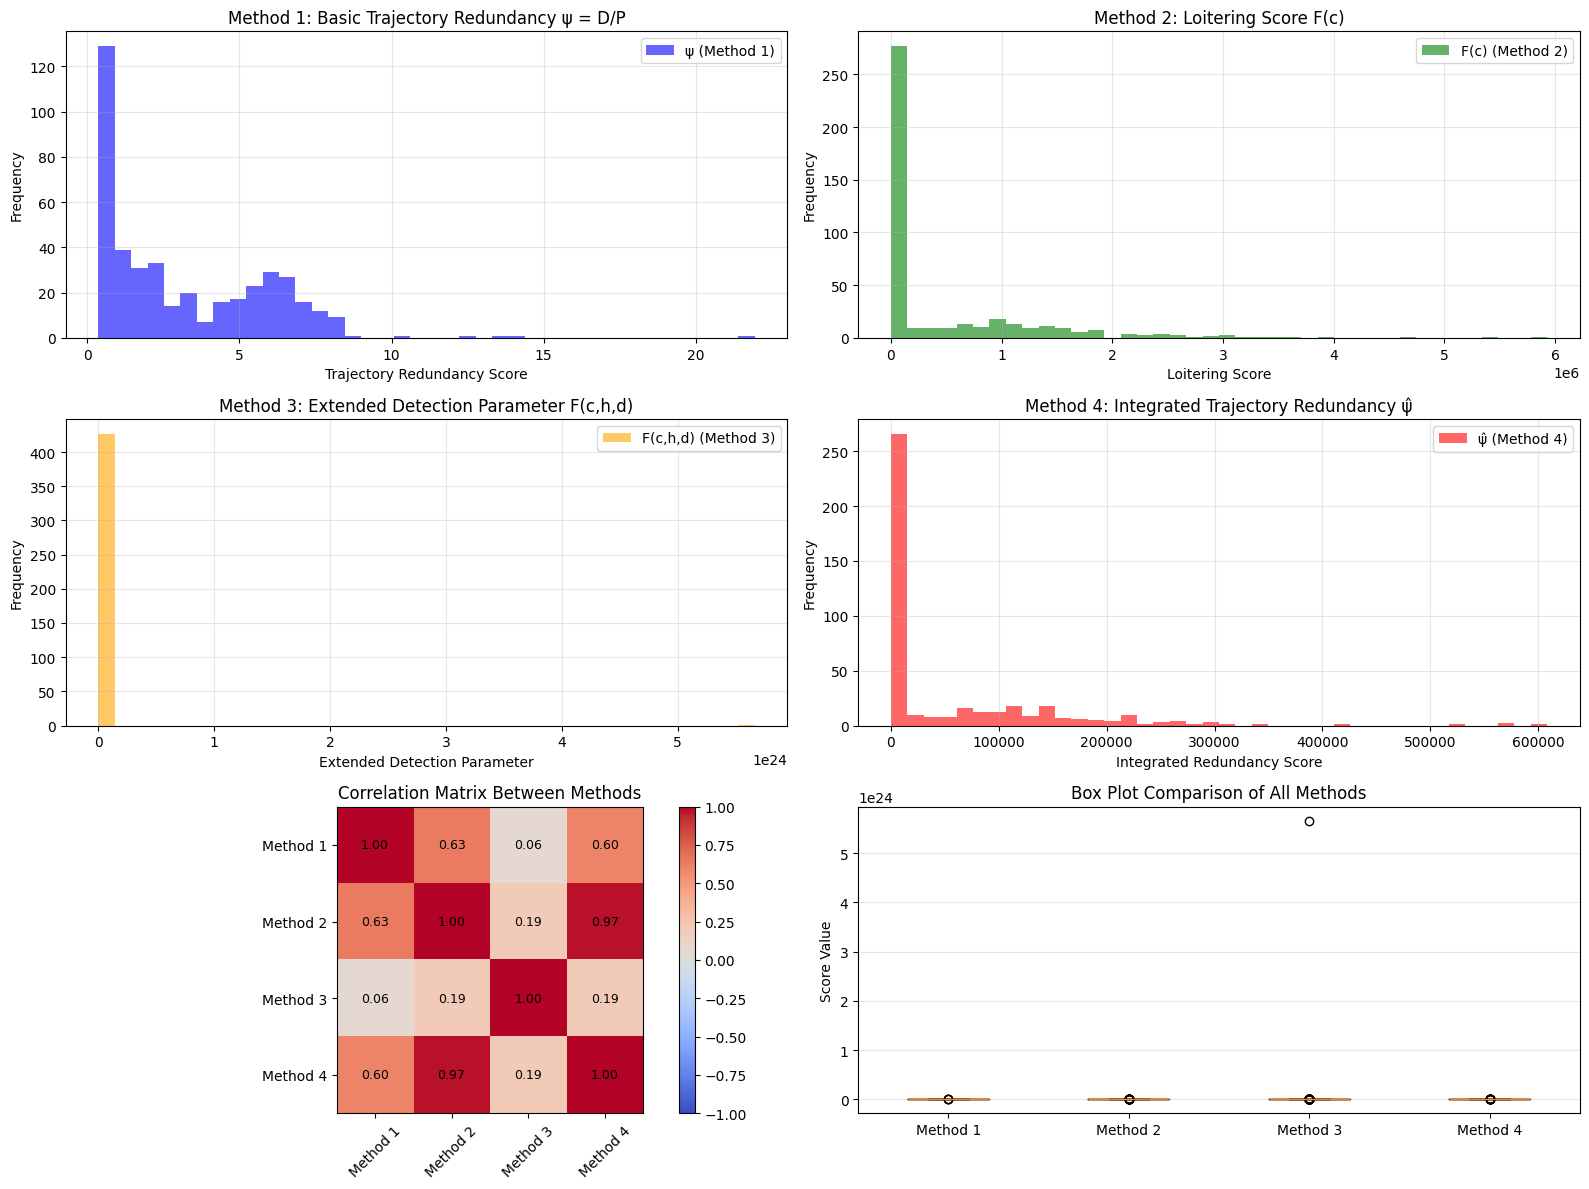


LOITERING VESSEL IDENTIFICATION

Method 1 (ψ > 5.5244, 75th percentile): 107 vessels
     MMSI  method1_psi  num_points
367106880    21.936723          97
316015121    14.204008          97
316013007    13.711830          97
303457000    12.517406          97
367657950    10.368757          97
366772990     8.603900          97
368926043     8.419203          97
367143770     8.335480          97
367513050     8.190961          97
366929780     8.175855          97

Method 2 (F(c) > 778793.0779, 75th percentile): 107 vessels
     MMSI   method2_Fc  num_points
316018616 5.928590e+06          97
316206000 5.384038e+06          97
316037746 4.733957e+06          97
316025676 3.876205e+06          97
366929780 3.612798e+06          97
368037750 3.420866e+06          97
316039951 3.388785e+06          97
366971980 3.238281e+06          97
367709830 3.088637e+06          97
316018399 2.977754e+06          97

Method 3 (F(c,h,d) > 419569521164319.1250, 75th percentile): 107 vessels
     MMSI

In [4]:
# ==================== VISUALIZATION AND COMPARISON ====================


def plot_method_comparison(results_df, figsize=(16, 12)):
    """
    Create comprehensive visualization comparing all four methods.
    """
    fig, axes = plt.subplots(3, 2, figsize=figsize)

    # Plot 1: Distribution of each method
    ax = axes[0, 0]
    ax.hist(
        results_df["method1_psi"].dropna(),
        bins=40,
        alpha=0.6,
        label="ψ (Method 1)",
        color="blue",
    )
    ax.set_xlabel("Trajectory Redundancy Score")
    ax.set_ylabel("Frequency")
    ax.set_title("Method 1: Basic Trajectory Redundancy ψ = D/P")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.hist(
        results_df["method2_Fc"].dropna(),
        bins=40,
        alpha=0.6,
        label="F(c) (Method 2)",
        color="green",
    )
    ax.set_xlabel("Loitering Score")
    ax.set_ylabel("Frequency")
    ax.set_title("Method 2: Loitering Score F(c)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.hist(
        results_df["method3_Fchd"].dropna(),
        bins=40,
        alpha=0.6,
        label="F(c,h,d) (Method 3)",
        color="orange",
    )
    ax.set_xlabel("Extended Detection Parameter")
    ax.set_ylabel("Frequency")
    ax.set_title("Method 3: Extended Detection Parameter F(c,h,d)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.hist(
        results_df["method4_psi_hat"].dropna(),
        bins=40,
        alpha=0.6,
        label="ψ̂ (Method 4)",
        color="red",
    )
    ax.set_xlabel("Integrated Redundancy Score")
    ax.set_ylabel("Frequency")
    ax.set_title("Method 4: Integrated Trajectory Redundancy ψ̂")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 5: Correlation between methods
    ax = axes[2, 0]
    valid_data = results_df[
        ["method1_psi", "method2_Fc", "method3_Fchd", "method4_psi_hat"]
    ].dropna()
    if len(valid_data) > 10:
        corr_matrix = valid_data.corr()
        im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr_matrix.columns)))
        ax.set_yticks(range(len(corr_matrix.columns)))
        ax.set_xticklabels(
            ["Method 1", "Method 2", "Method 3", "Method 4"], rotation=45
        )
        ax.set_yticklabels(["Method 1", "Method 2", "Method 3", "Method 4"])
        ax.set_title("Correlation Matrix Between Methods")
        plt.colorbar(im, ax=ax)

        # Add correlation values
        for i in range(len(corr_matrix)):
            for j in range(len(corr_matrix)):
                text = ax.text(
                    j,
                    i,
                    f"{corr_matrix.iloc[i, j]:.2f}",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=9,
                )

    # Plot 6: Box plot comparison
    ax = axes[2, 1]
    data_to_plot = [
        results_df["method1_psi"].dropna(),
        results_df["method2_Fc"].dropna(),
        results_df["method3_Fchd"].dropna(),
        results_df["method4_psi_hat"].dropna(),
    ]
    bp = ax.boxplot(
        data_to_plot, labels=["Method 1", "Method 2", "Method 3", "Method 4"]
    )
    ax.set_ylabel("Score Value")
    ax.set_title("Box Plot Comparison of All Methods")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


def identify_loitering_vessels(results_df, percentile=75):
    """
    Identify vessels with high loitering scores across different methods.
    """
    print("\n" + "=" * 90)
    print("LOITERING VESSEL IDENTIFICATION")
    print("=" * 90)

    # Method 1 - High ψ
    m1_threshold = results_df["method1_psi"].quantile(percentile / 100)
    m1_high = results_df[results_df["method1_psi"] > m1_threshold].sort_values(
        "method1_psi", ascending=False
    )

    print(
        f"\nMethod 1 (ψ > {m1_threshold:.4f}, {percentile}th percentile): {len(m1_high)} vessels"
    )
    print(
        m1_high[["MMSI", "method1_psi", "num_points"]].head(10).to_string(index=False)
    )

    # Method 2 - High F(c)
    m2_threshold = results_df["method2_Fc"].quantile(percentile / 100)
    m2_high = results_df[results_df["method2_Fc"] > m2_threshold].sort_values(
        "method2_Fc", ascending=False
    )

    print(
        f"\nMethod 2 (F(c) > {m2_threshold:.4f}, {percentile}th percentile): {len(m2_high)} vessels"
    )
    print(m2_high[["MMSI", "method2_Fc", "num_points"]].head(10).to_string(index=False))

    # Method 3 - High F(c,h,d)
    m3_threshold = results_df["method3_Fchd"].quantile(percentile / 100)
    m3_high = results_df[results_df["method3_Fchd"] > m3_threshold].sort_values(
        "method3_Fchd", ascending=False
    )

    print(
        f"\nMethod 3 (F(c,h,d) > {m3_threshold:.4f}, {percentile}th percentile): {len(m3_high)} vessels"
    )
    print(
        m3_high[["MMSI", "method3_Fchd", "num_points"]].head(10).to_string(index=False)
    )

    # Method 4 - High ψ̂
    m4_threshold = results_df["method4_psi_hat"].quantile(percentile / 100)
    m4_high = results_df[results_df["method4_psi_hat"] > m4_threshold].sort_values(
        "method4_psi_hat", ascending=False
    )

    print(
        f"\nMethod 4 (ψ̂ > {m4_threshold:.4f}, {percentile}th percentile): {len(m4_high)} vessels"
    )
    print(
        m4_high[["MMSI", "method4_psi_hat", "num_points"]]
        .head(10)
        .to_string(index=False)
    )

    # Vessels flagged by multiple methods
    print(f"\n{'─'*90}")
    print("VESSELS FLAGGED BY MULTIPLE METHODS (Consensus Loitering)")
    print(f"{'─'*90}")

    high_in_all = (
        set(m1_high.index)
        & set(m2_high.index)
        & set(m3_high.index)
        & set(m4_high.index)
    )
    high_in_3 = set(m1_high.index) & set(m2_high.index) & set(m3_high.index)
    high_in_2 = set(m1_high.index) & set(m2_high.index)

    print(f"Flagged by all 4 methods: {len(high_in_all)} vessels")
    print(f"Flagged by 3+ methods: {len(high_in_3)} vessels")
    print(f"Flagged by 2+ methods: {len(high_in_2)} vessels")

    return {
        "method1": m1_high,
        "method2": m2_high,
        "method3": m3_high,
        "method4": m4_high,
        "consensus_all_4": high_in_all,
        "consensus_3": high_in_3,
        "consensus_2": high_in_2,
    }


# Create visualizations
print("\nGenerating comparison visualizations...")
plot_method_comparison(results_df)

# Identify loitering vessels
loitering_analysis = identify_loitering_vessels(results_df, percentile=75)


VISUALIZING TOP 15 LOITERING VESSELS WITH SMALLER ARROWS AND HORIZONTAL METRIC PLOTS


Vessel 1/15: MMSI 367106880
  ψ (Method 1): 21.936723
  F(c) (Method 2): 1.146307e+05
  F(c,h,d) (Method 3): 1.005784e+14
  ψ̂ (Method 4): 2065.153381


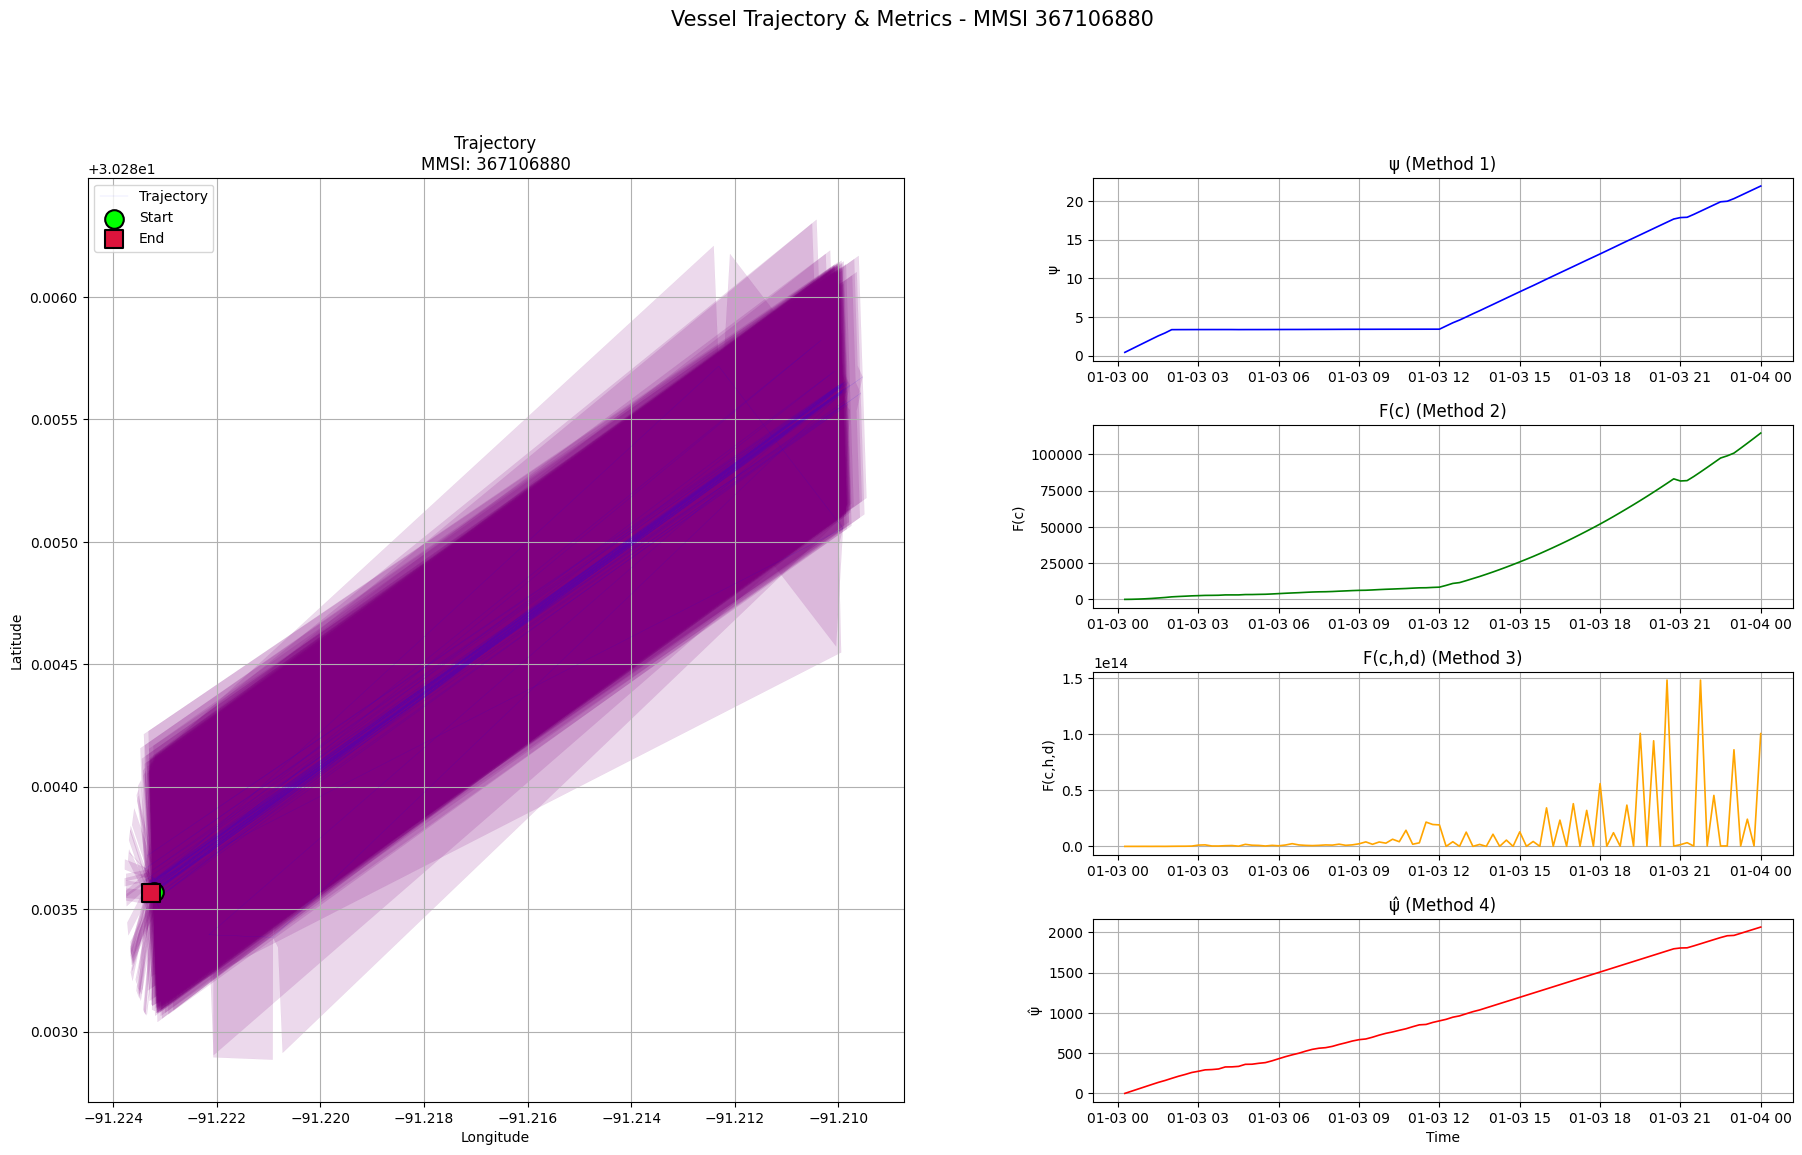


Vessel 2/15: MMSI 316015121
  ψ (Method 1): 14.204008
  F(c) (Method 2): 8.389654e+03
  F(c,h,d) (Method 3): 1.356188e+12
  ψ̂ (Method 4): 407.464283


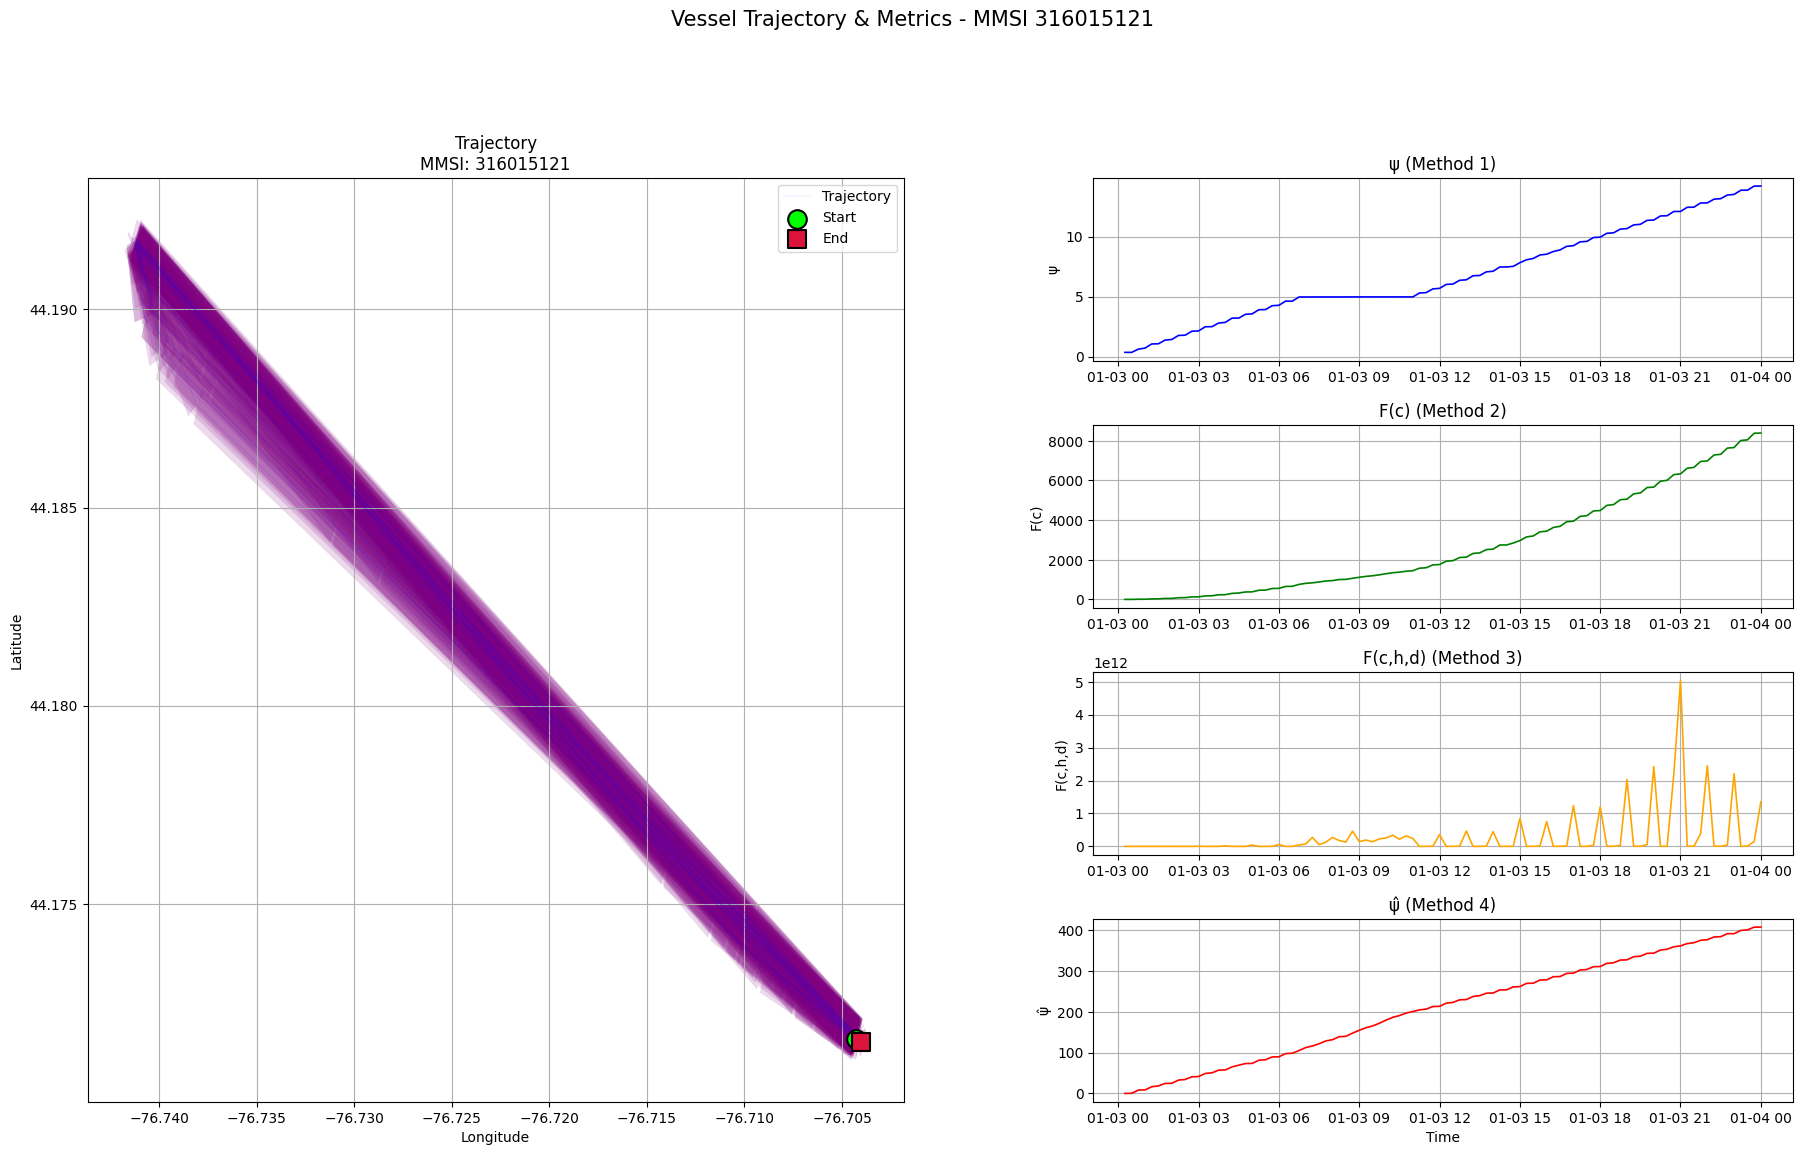


Vessel 3/15: MMSI 316013007
  ψ (Method 1): 13.711830
  F(c) (Method 2): 5.304035e+03
  F(c,h,d) (Method 3): 4.849195e+12
  ψ̂ (Method 4): 262.581300


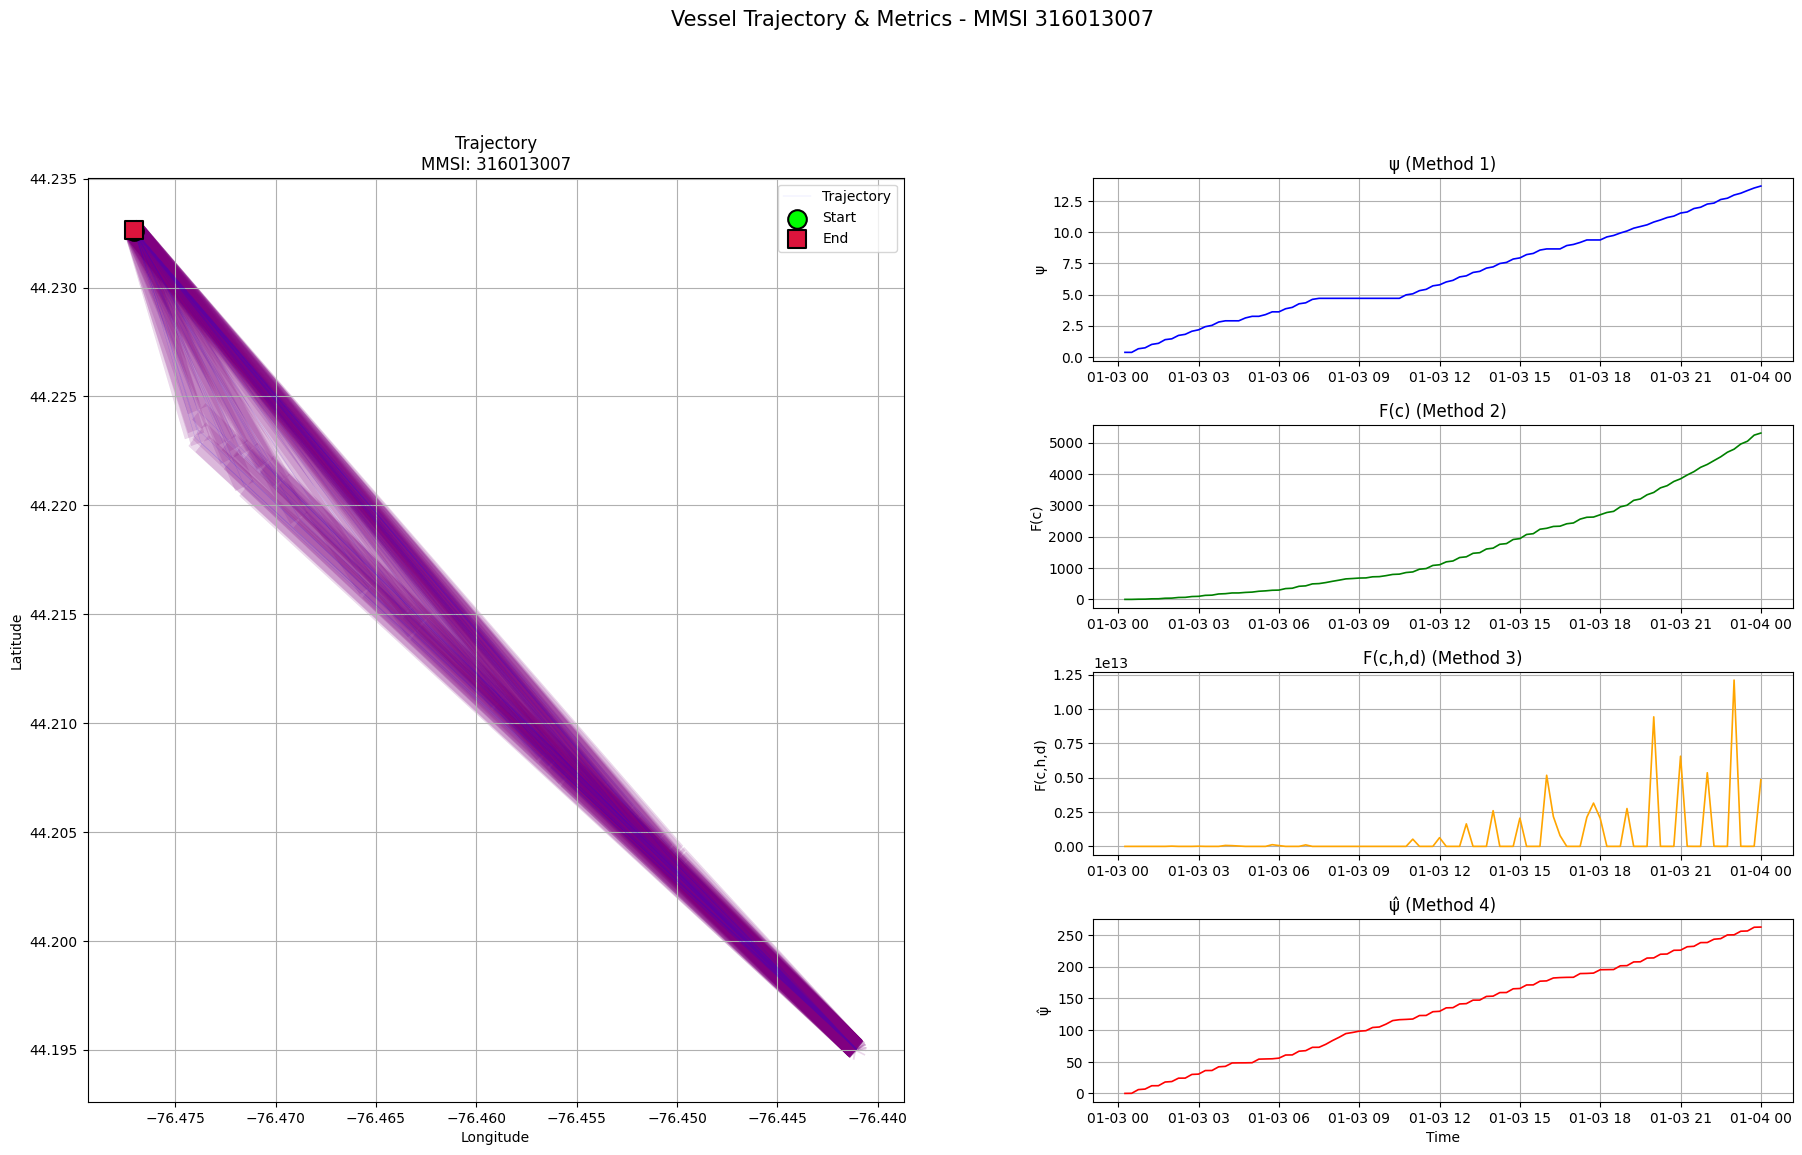


Vessel 4/15: MMSI 303457000
  ψ (Method 1): 12.517406
  F(c) (Method 2): 4.859140e+00
  F(c,h,d) (Method 3): 1.560350e+03
  ψ̂ (Method 4): 0.169413


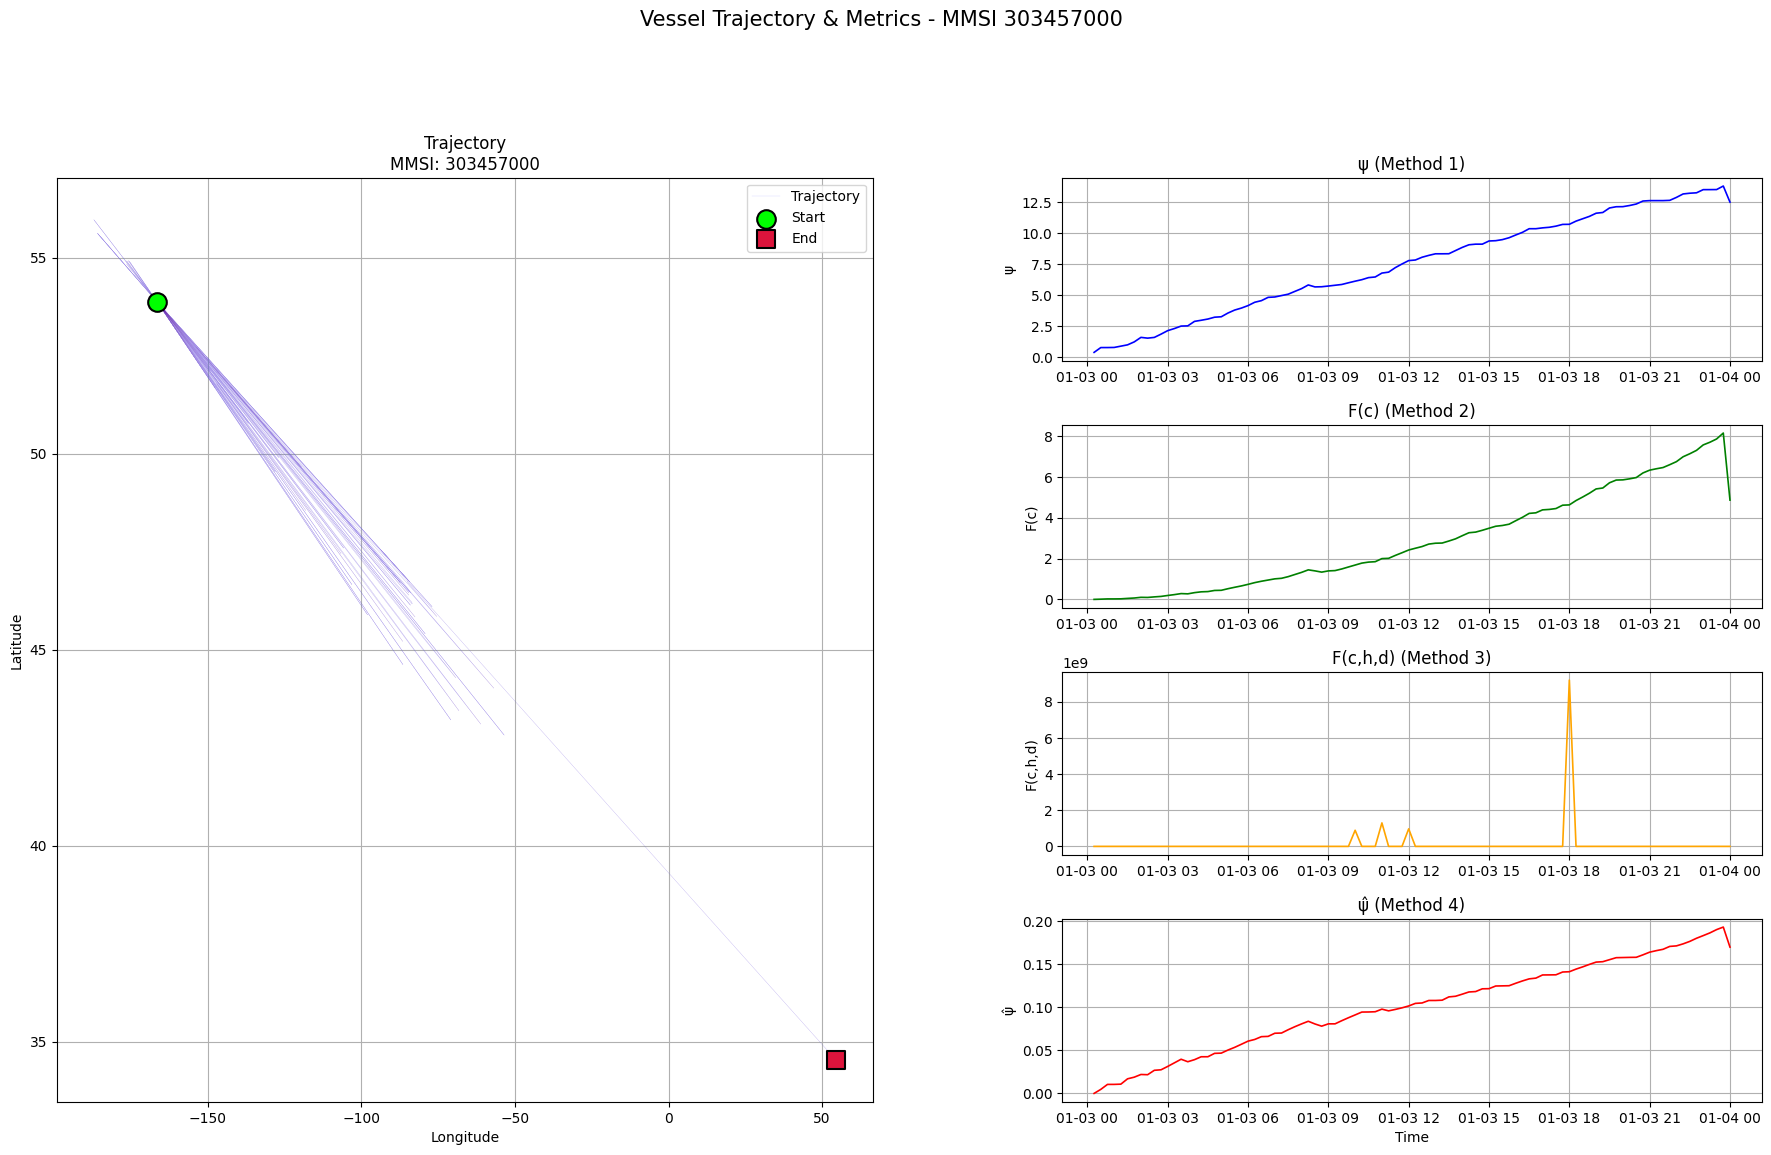


Vessel 5/15: MMSI 367657950
  ψ (Method 1): 10.368757
  F(c) (Method 2): 4.067607e+04
  F(c,h,d) (Method 3): 3.870727e+11
  ψ̂ (Method 4): 1676.862852


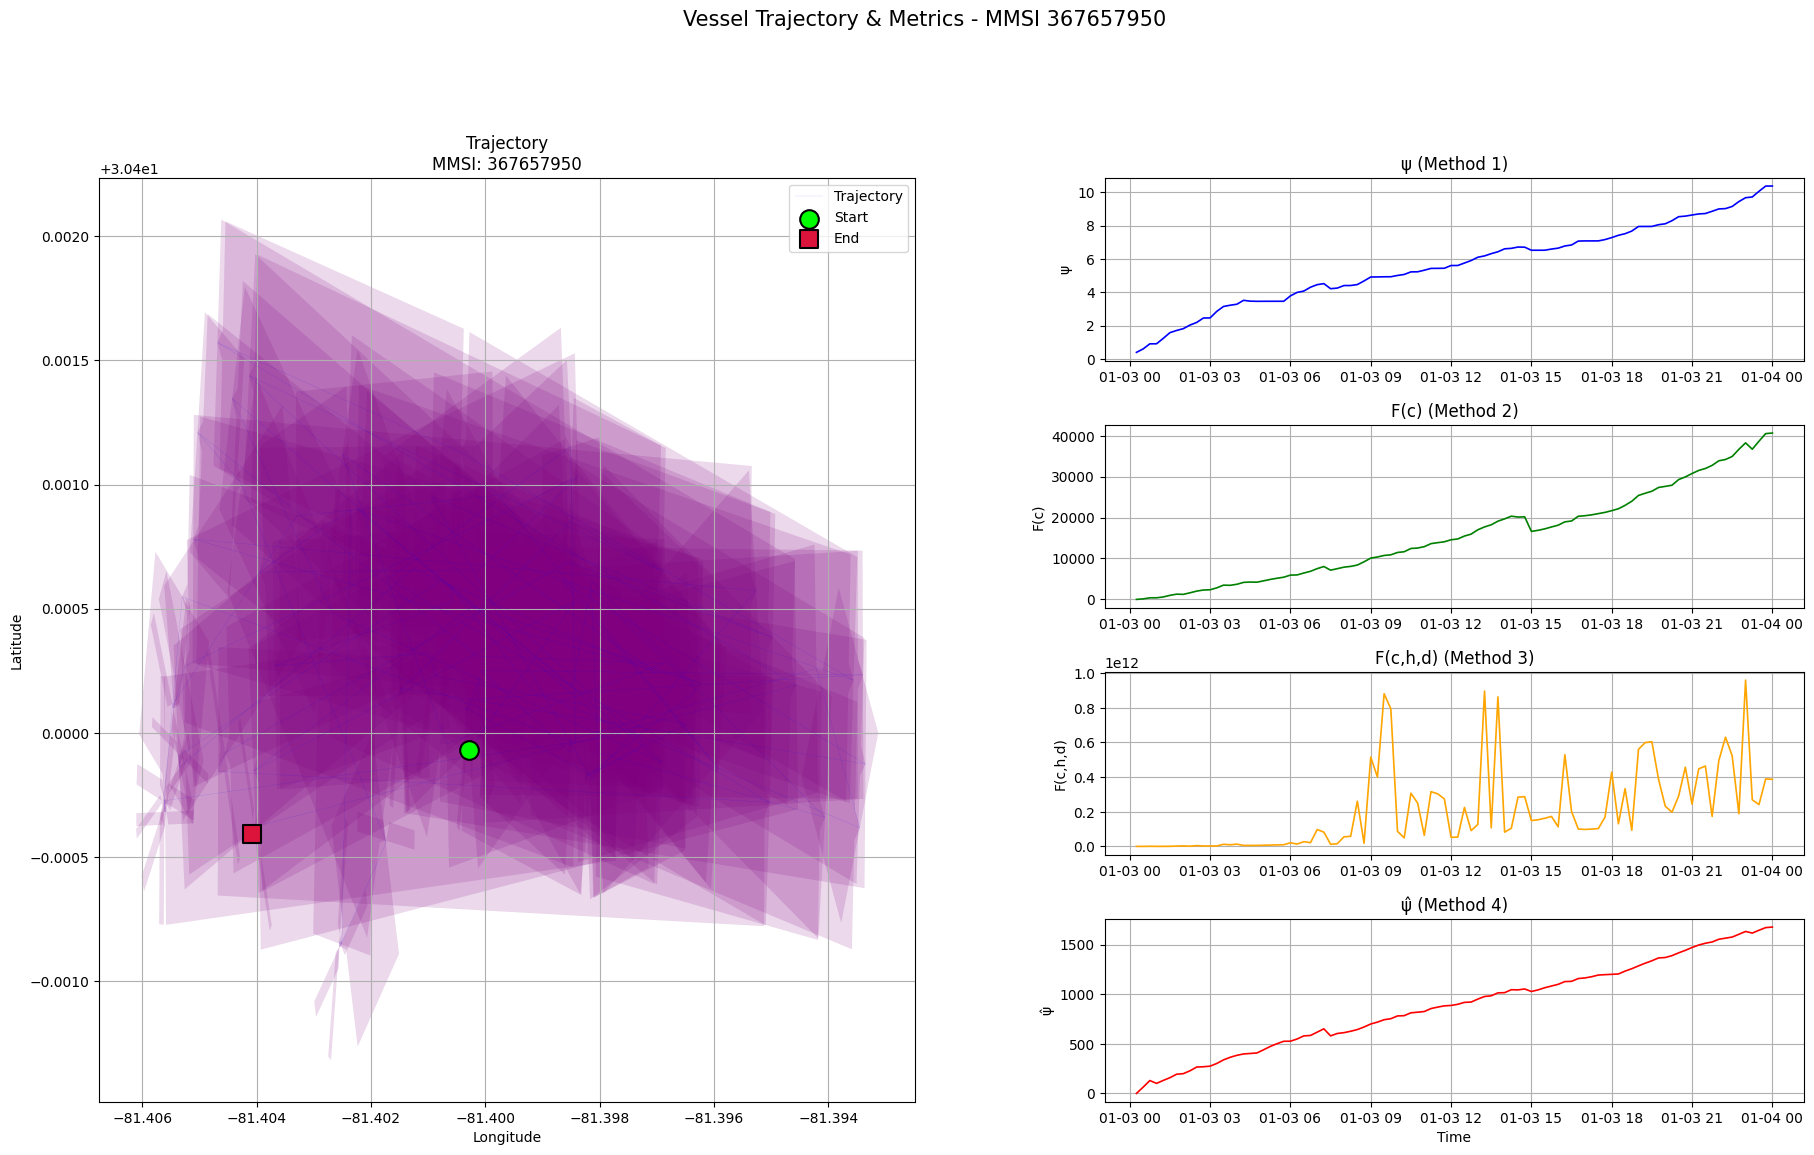


Vessel 6/15: MMSI 366772990
  ψ (Method 1): 8.603900
  F(c) (Method 2): 2.623964e+03
  F(c,h,d) (Method 3): 6.859462e+11
  ψ̂ (Method 4): 162.892780


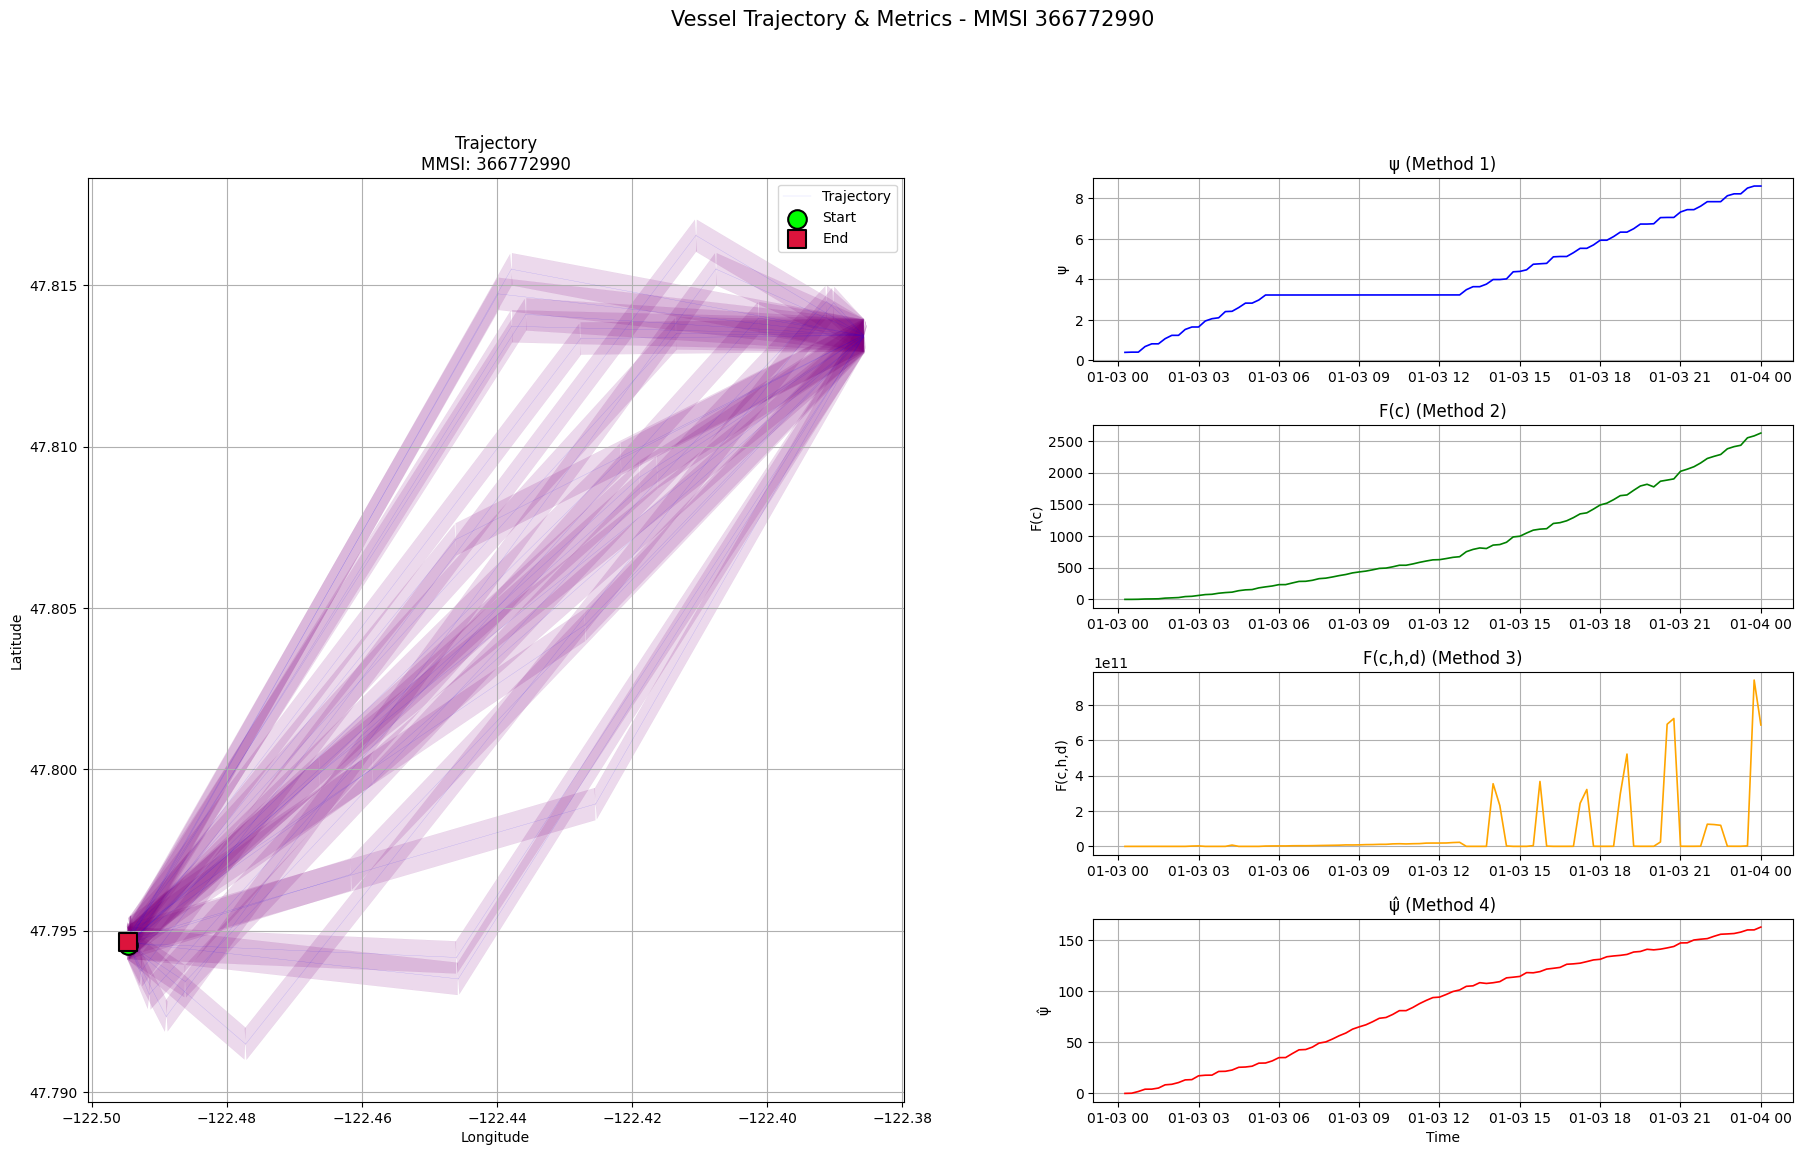


Vessel 7/15: MMSI 368926043
  ψ (Method 1): 8.419203
  F(c) (Method 2): 2.555531e+06
  F(c,h,d) (Method 3): 6.370227e+15
  ψ̂ (Method 4): 204346.562087


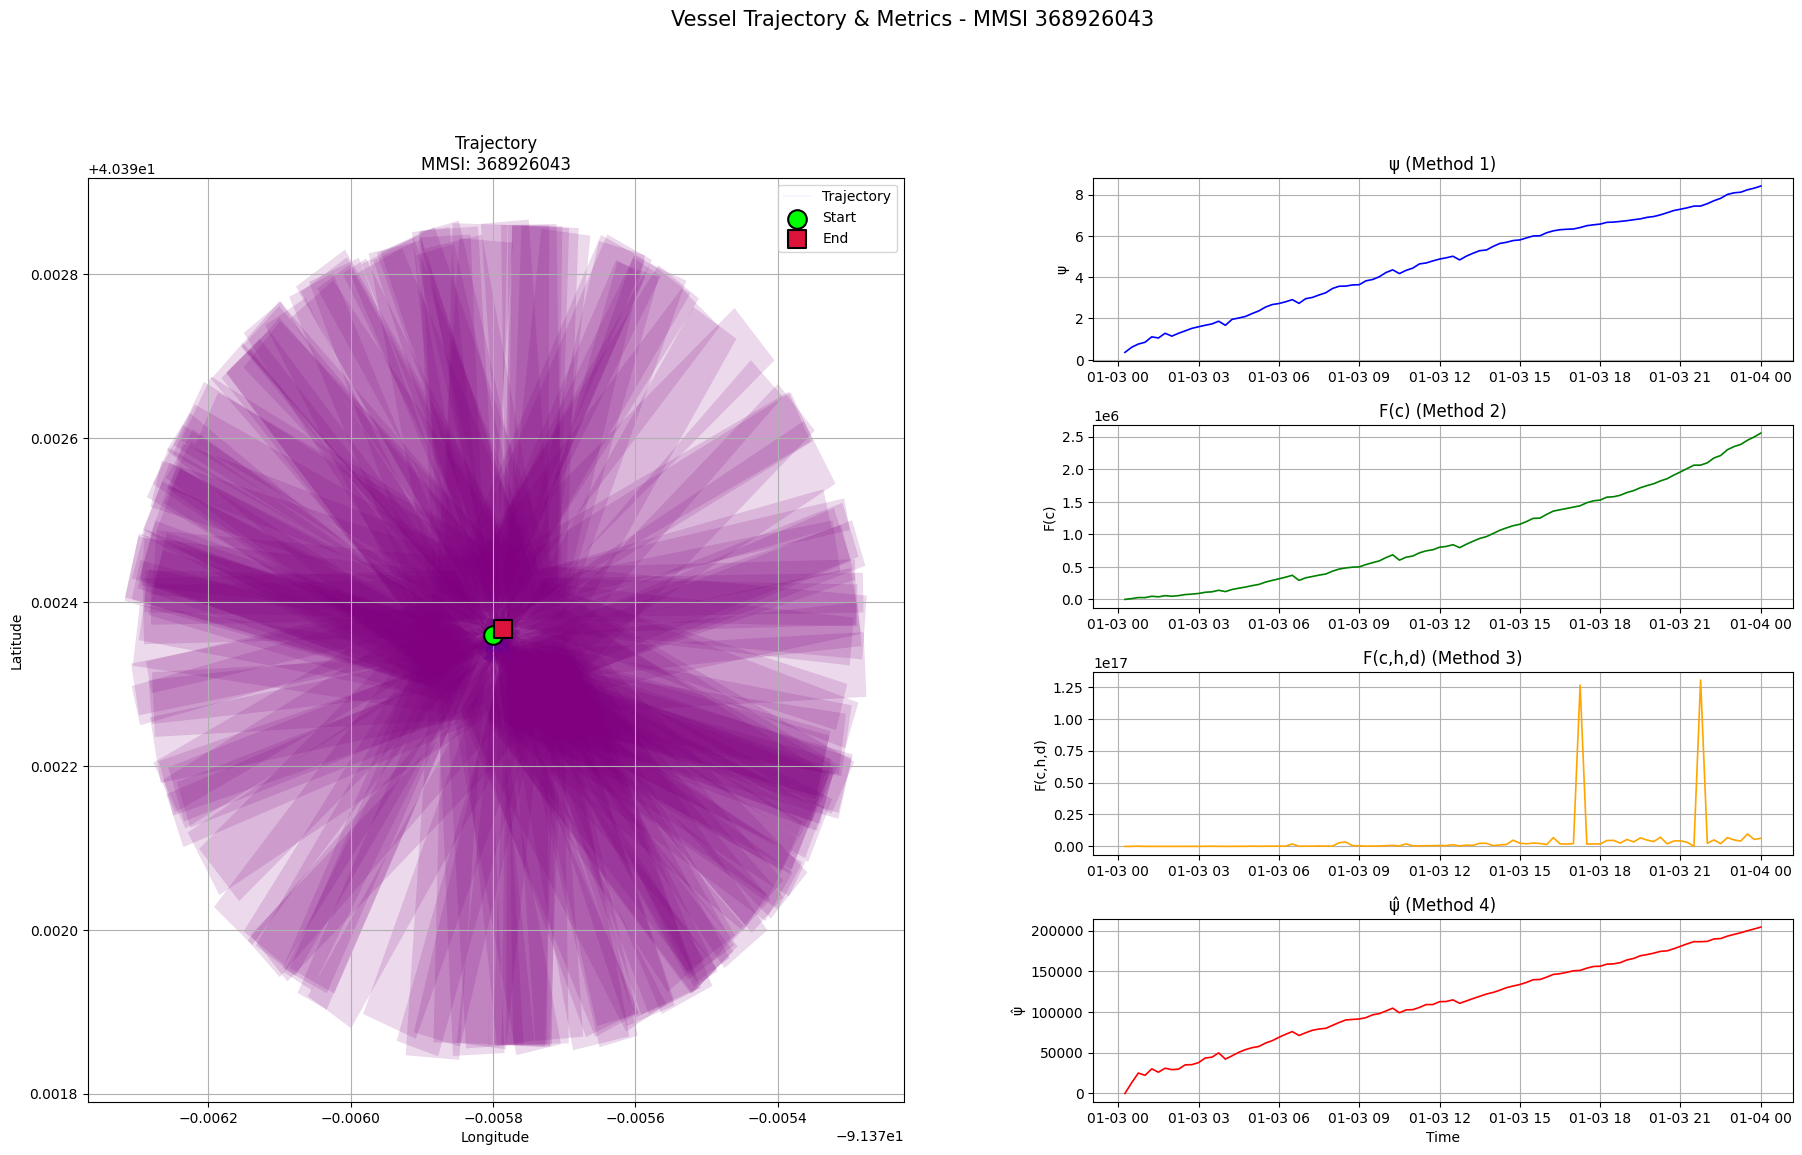


Vessel 8/15: MMSI 367143770
  ψ (Method 1): 8.335480
  F(c) (Method 2): 2.346743e+06
  F(c,h,d) (Method 3): 3.072486e+15
  ψ̂ (Method 4): 185443.145982


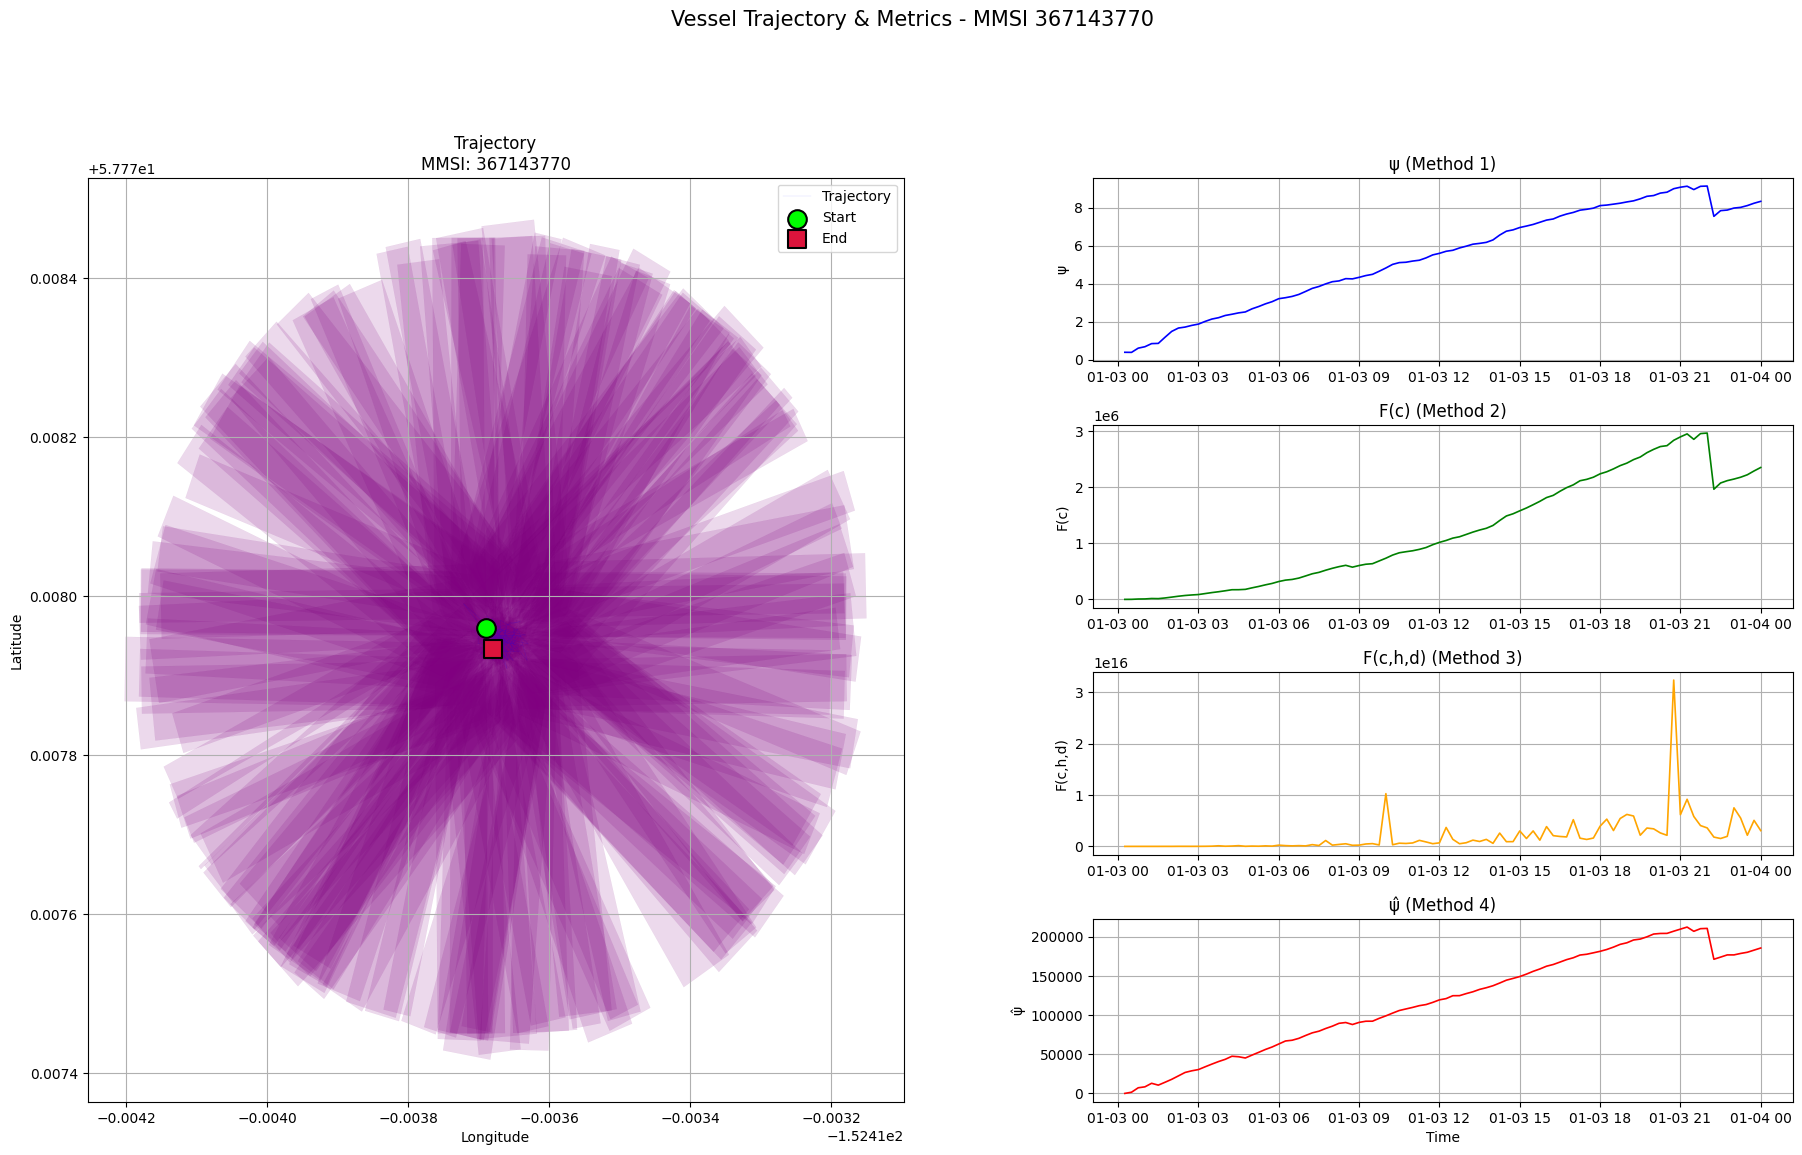


Vessel 9/15: MMSI 367513050
  ψ (Method 1): 8.190961
  F(c) (Method 2): 1.149098e+06
  F(c,h,d) (Method 3): 1.771480e+15
  ψ̂ (Method 4): 95395.842781


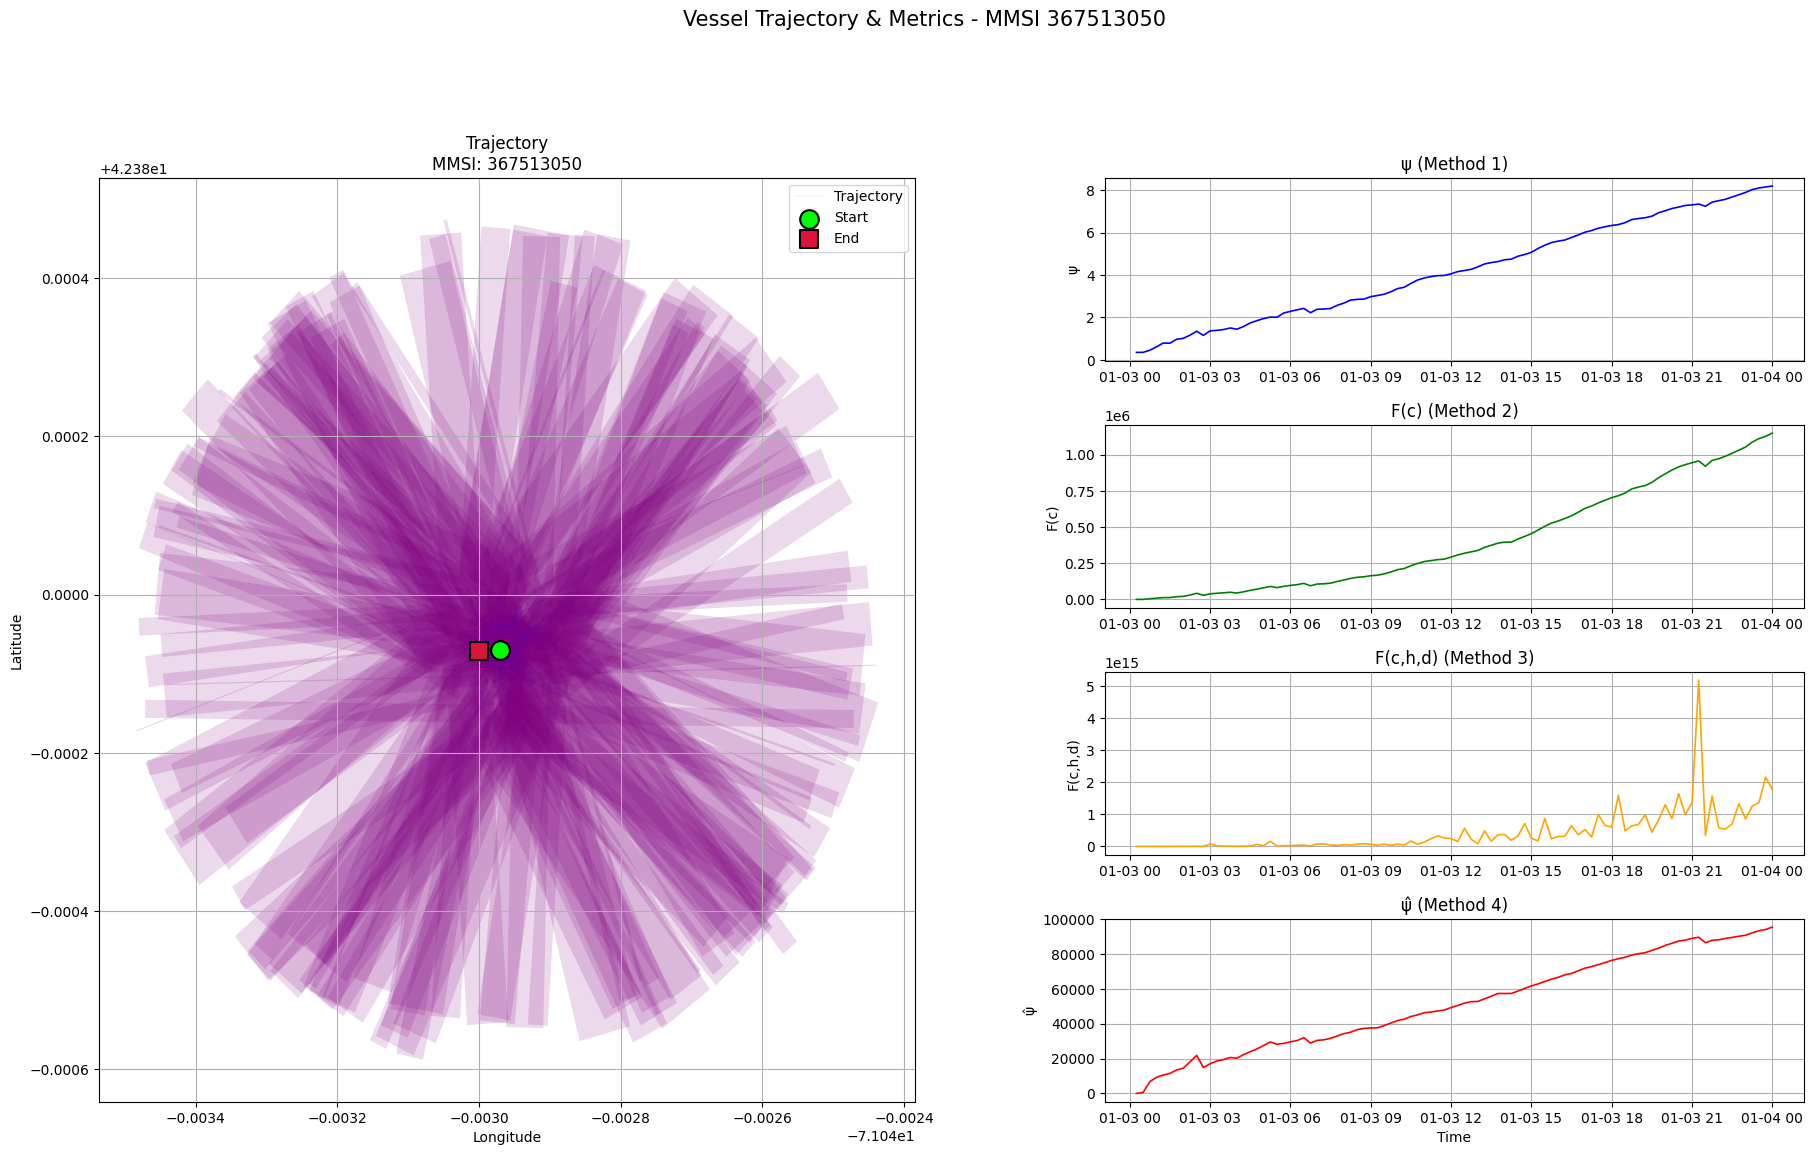


Vessel 10/15: MMSI 366929780
  ψ (Method 1): 8.175855
  F(c) (Method 2): 3.612798e+06
  F(c,h,d) (Method 3): 3.796845e+15
  ψ̂ (Method 4): 271987.675678


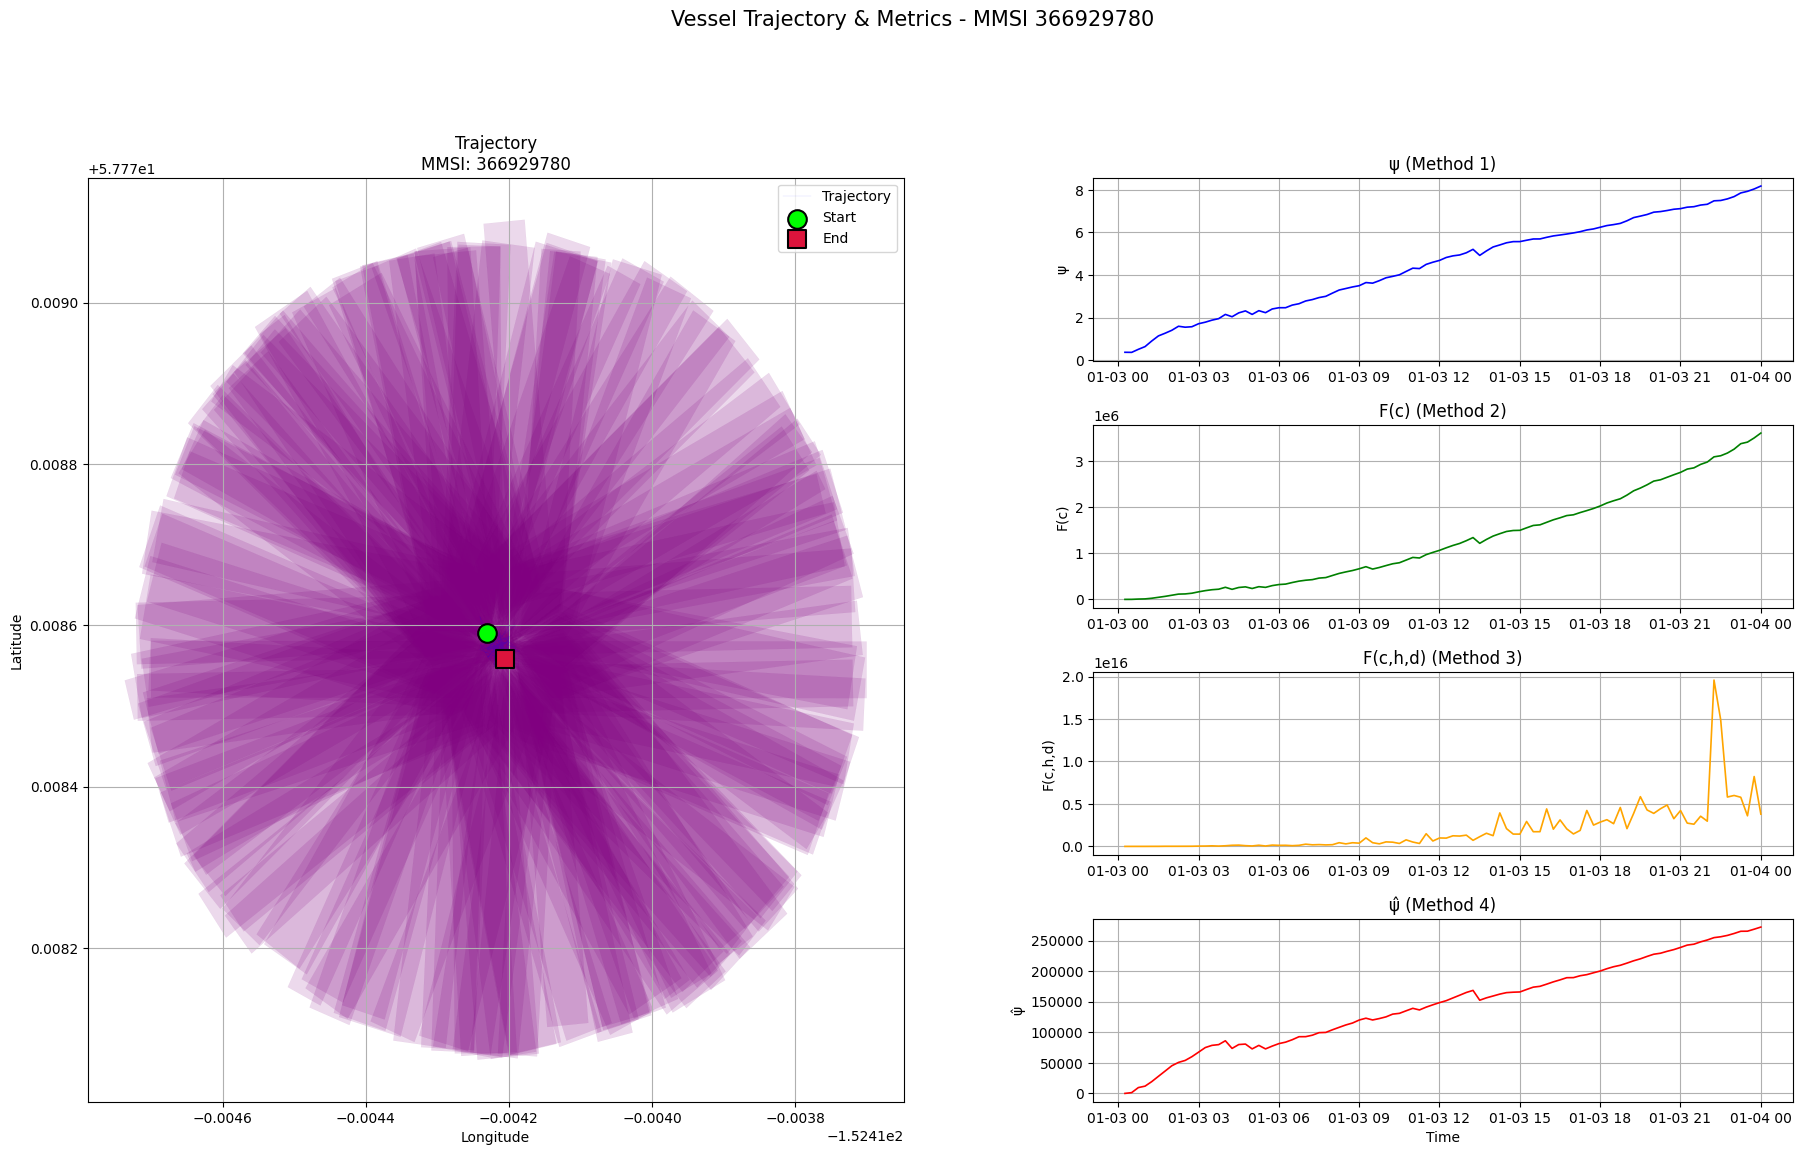


Vessel 11/15: MMSI 367473990
  ψ (Method 1): 8.159437
  F(c) (Method 2): 1.798432e+06
  F(c,h,d) (Method 3): 7.747620e+14
  ψ̂ (Method 4): 139709.643158


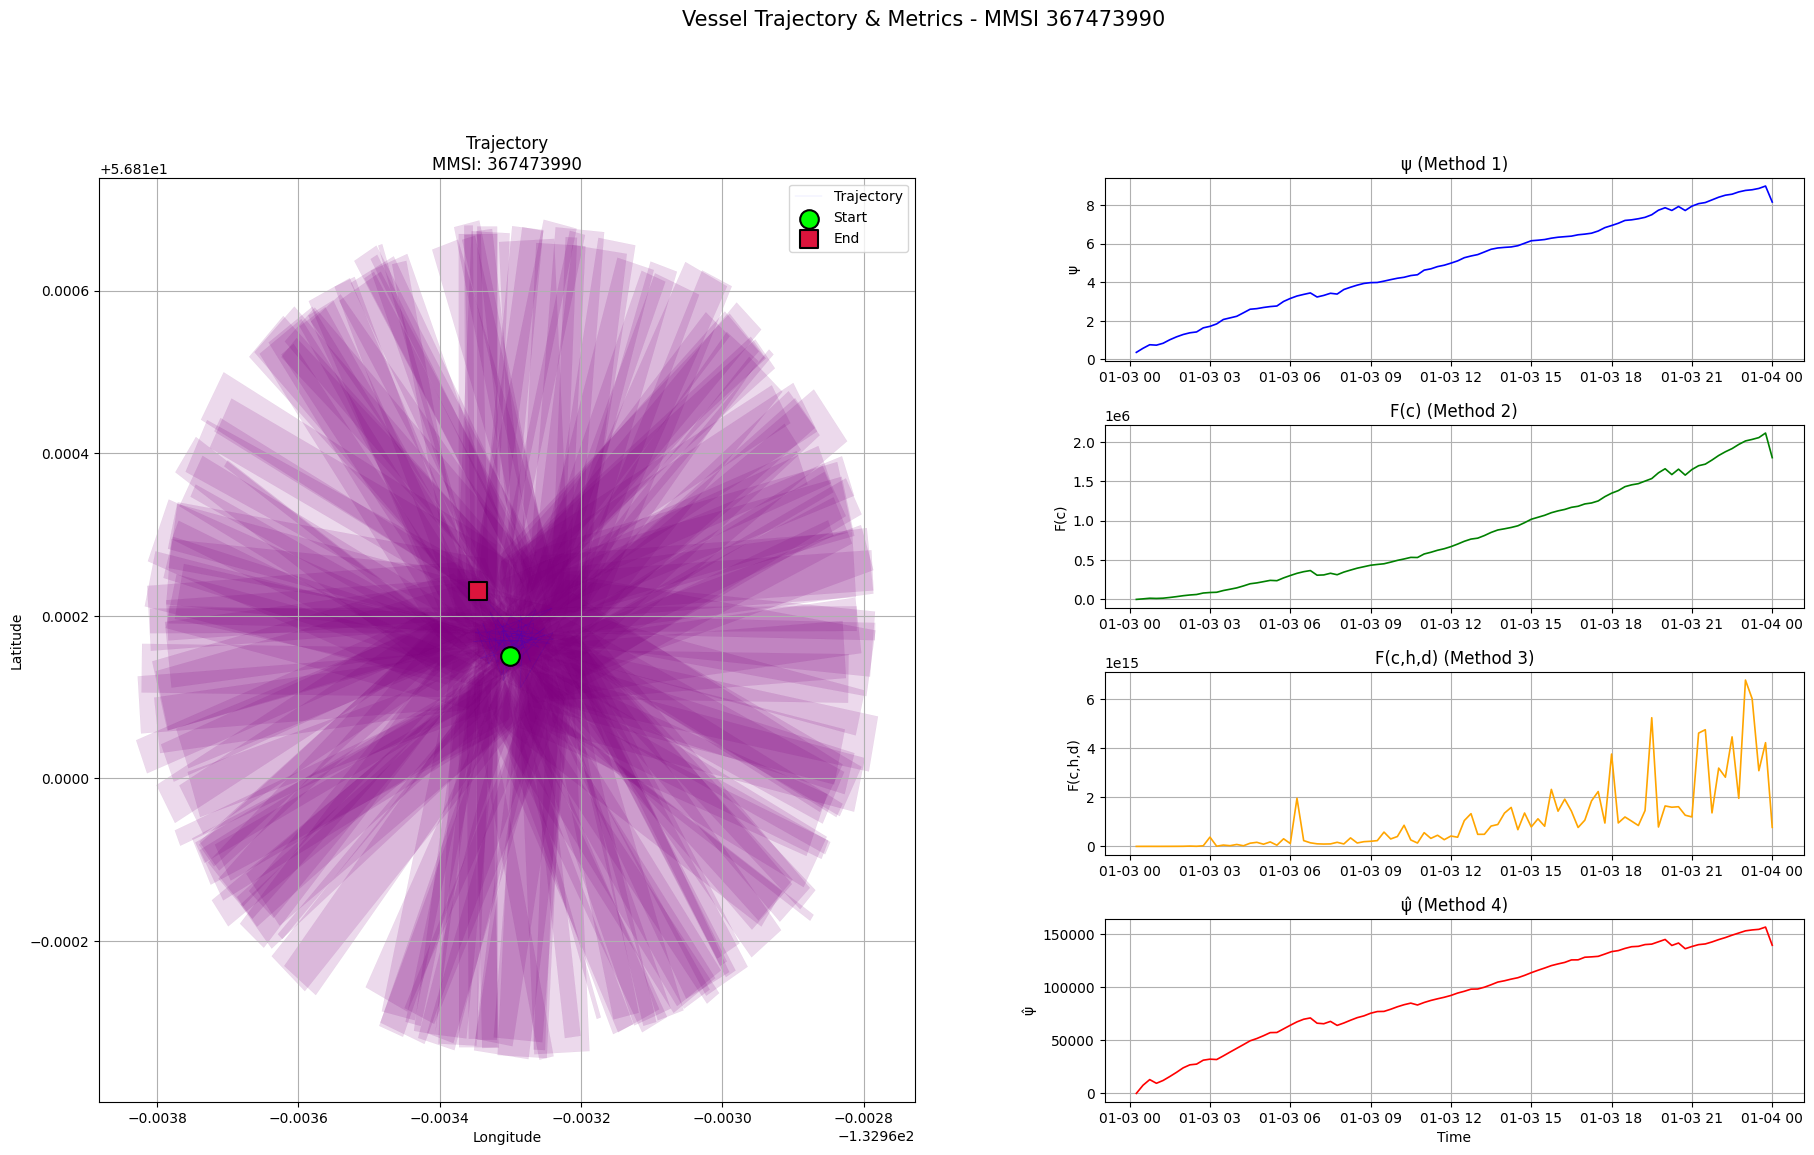


Vessel 12/15: MMSI 366978430
  ψ (Method 1): 8.126101
  F(c) (Method 2): 1.470541e+06
  F(c,h,d) (Method 3): 1.268542e+15
  ψ̂ (Method 4): 126678.573975


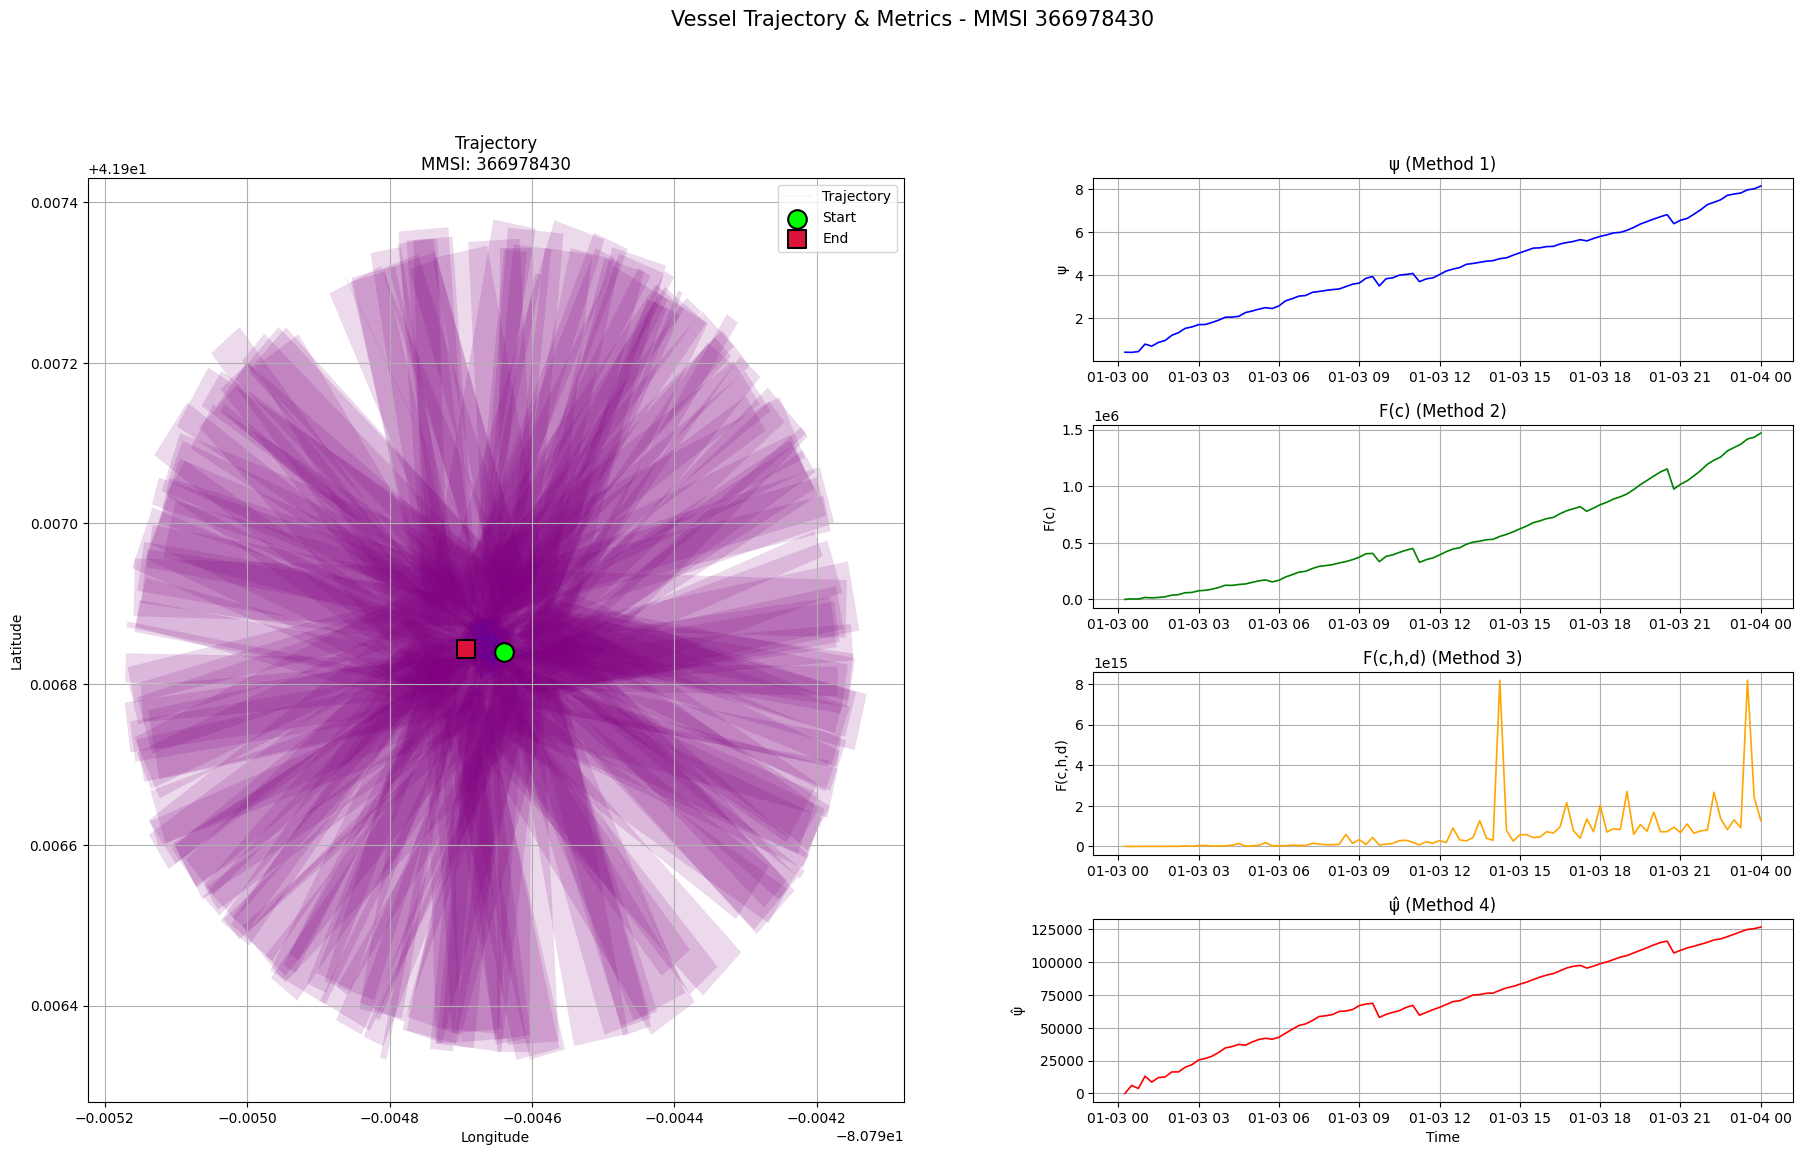


Vessel 13/15: MMSI 367662430
  ψ (Method 1): 8.049093
  F(c) (Method 2): 1.323772e+06
  F(c,h,d) (Method 3): 5.011561e+14
  ψ̂ (Method 4): 109681.759904


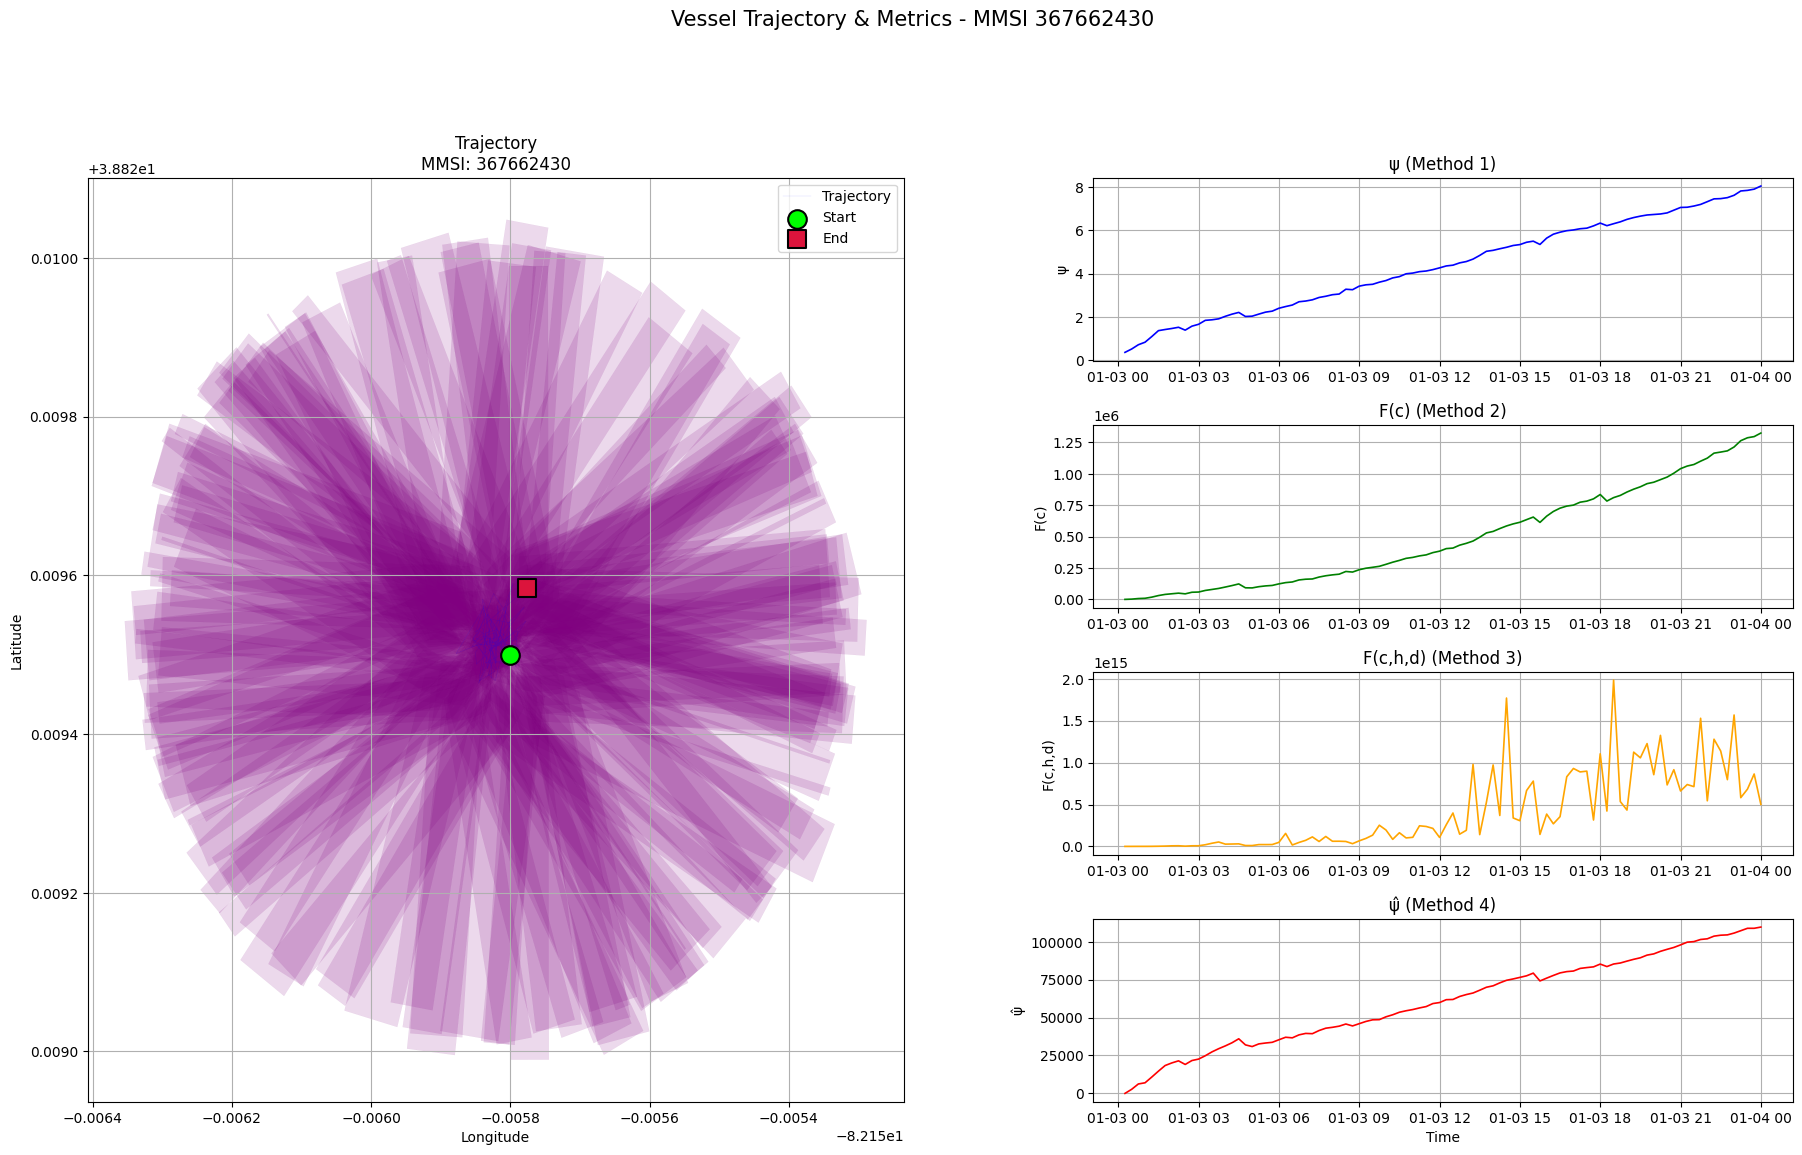


Vessel 14/15: MMSI 369970470
  ψ (Method 1): 8.026177
  F(c) (Method 2): 2.475027e+06
  F(c,h,d) (Method 3): 2.220305e+15
  ψ̂ (Method 4): 216113.651283


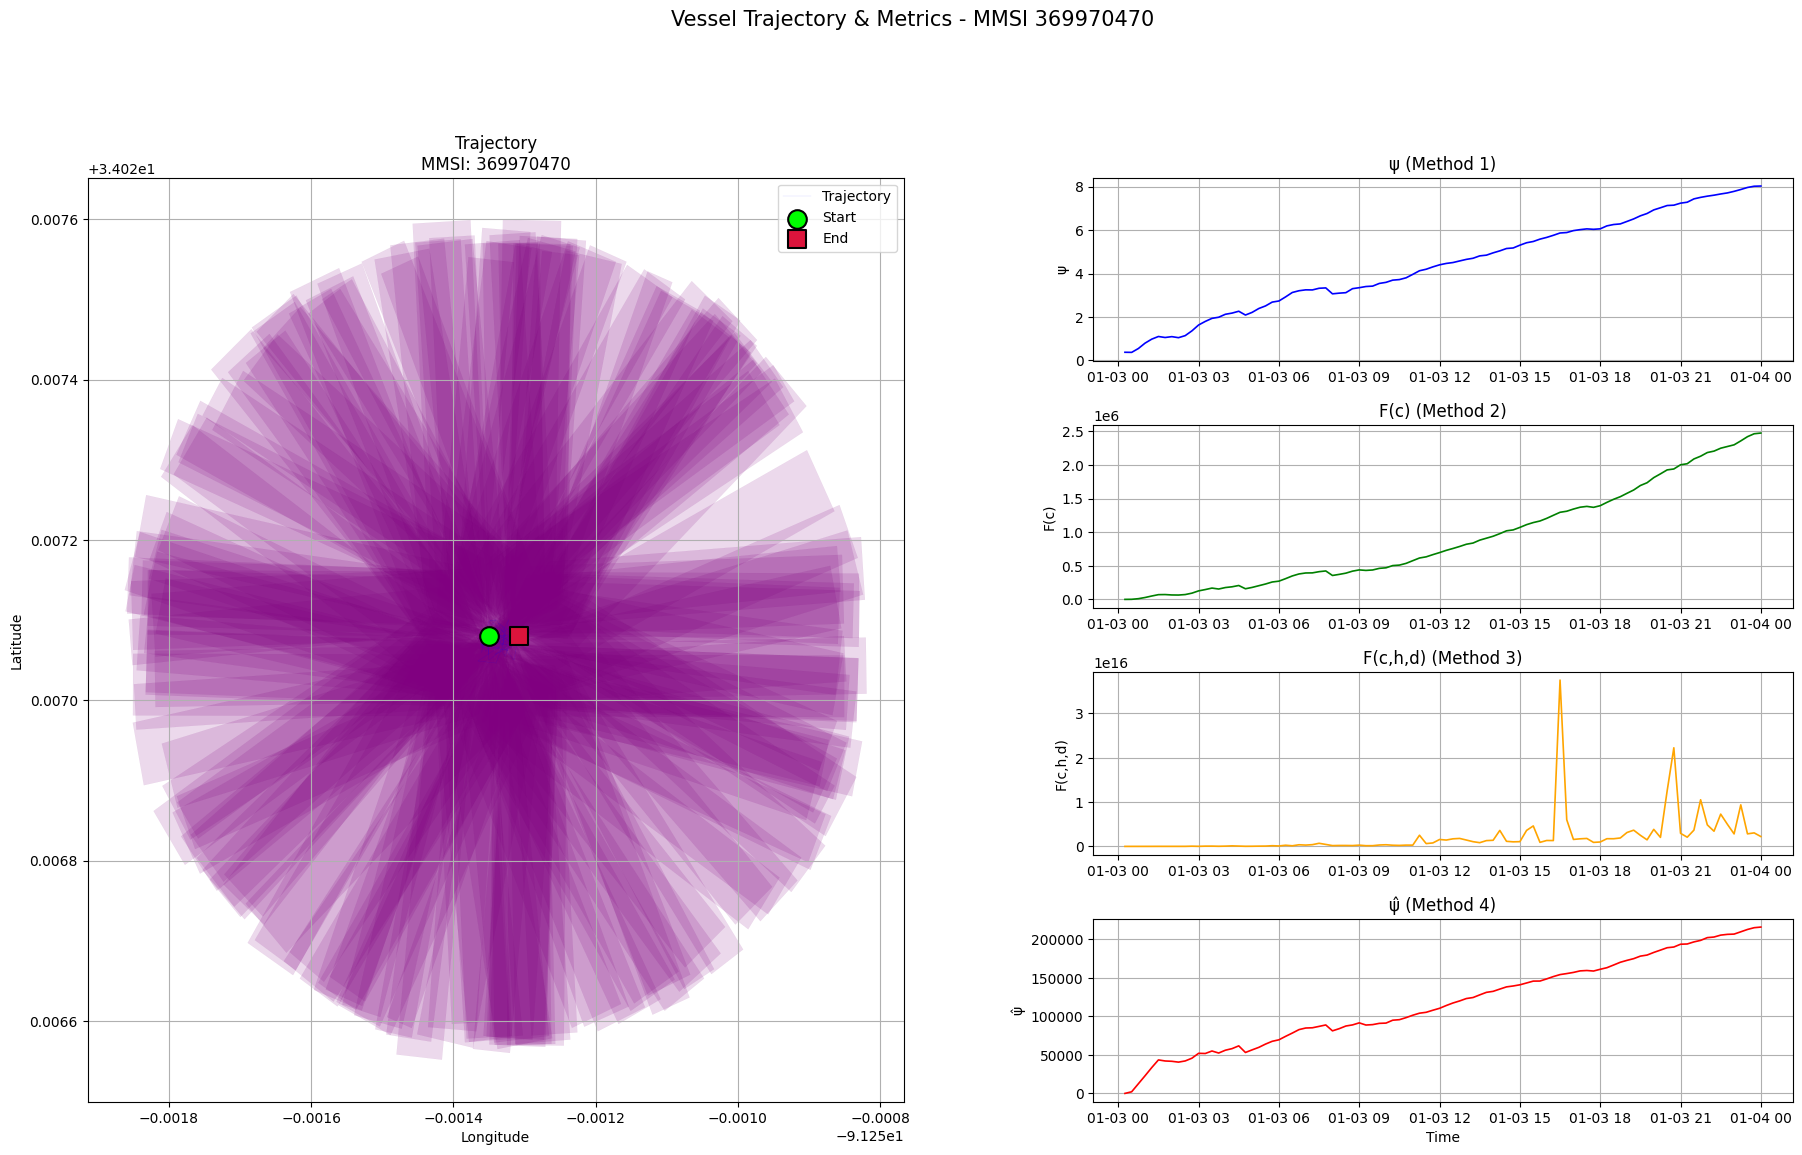


Vessel 15/15: MMSI 366988240
  ψ (Method 1): 7.946036
  F(c) (Method 2): 1.316580e+06
  F(c,h,d) (Method 3): 5.992298e+14
  ψ̂ (Method 4): 115819.908707


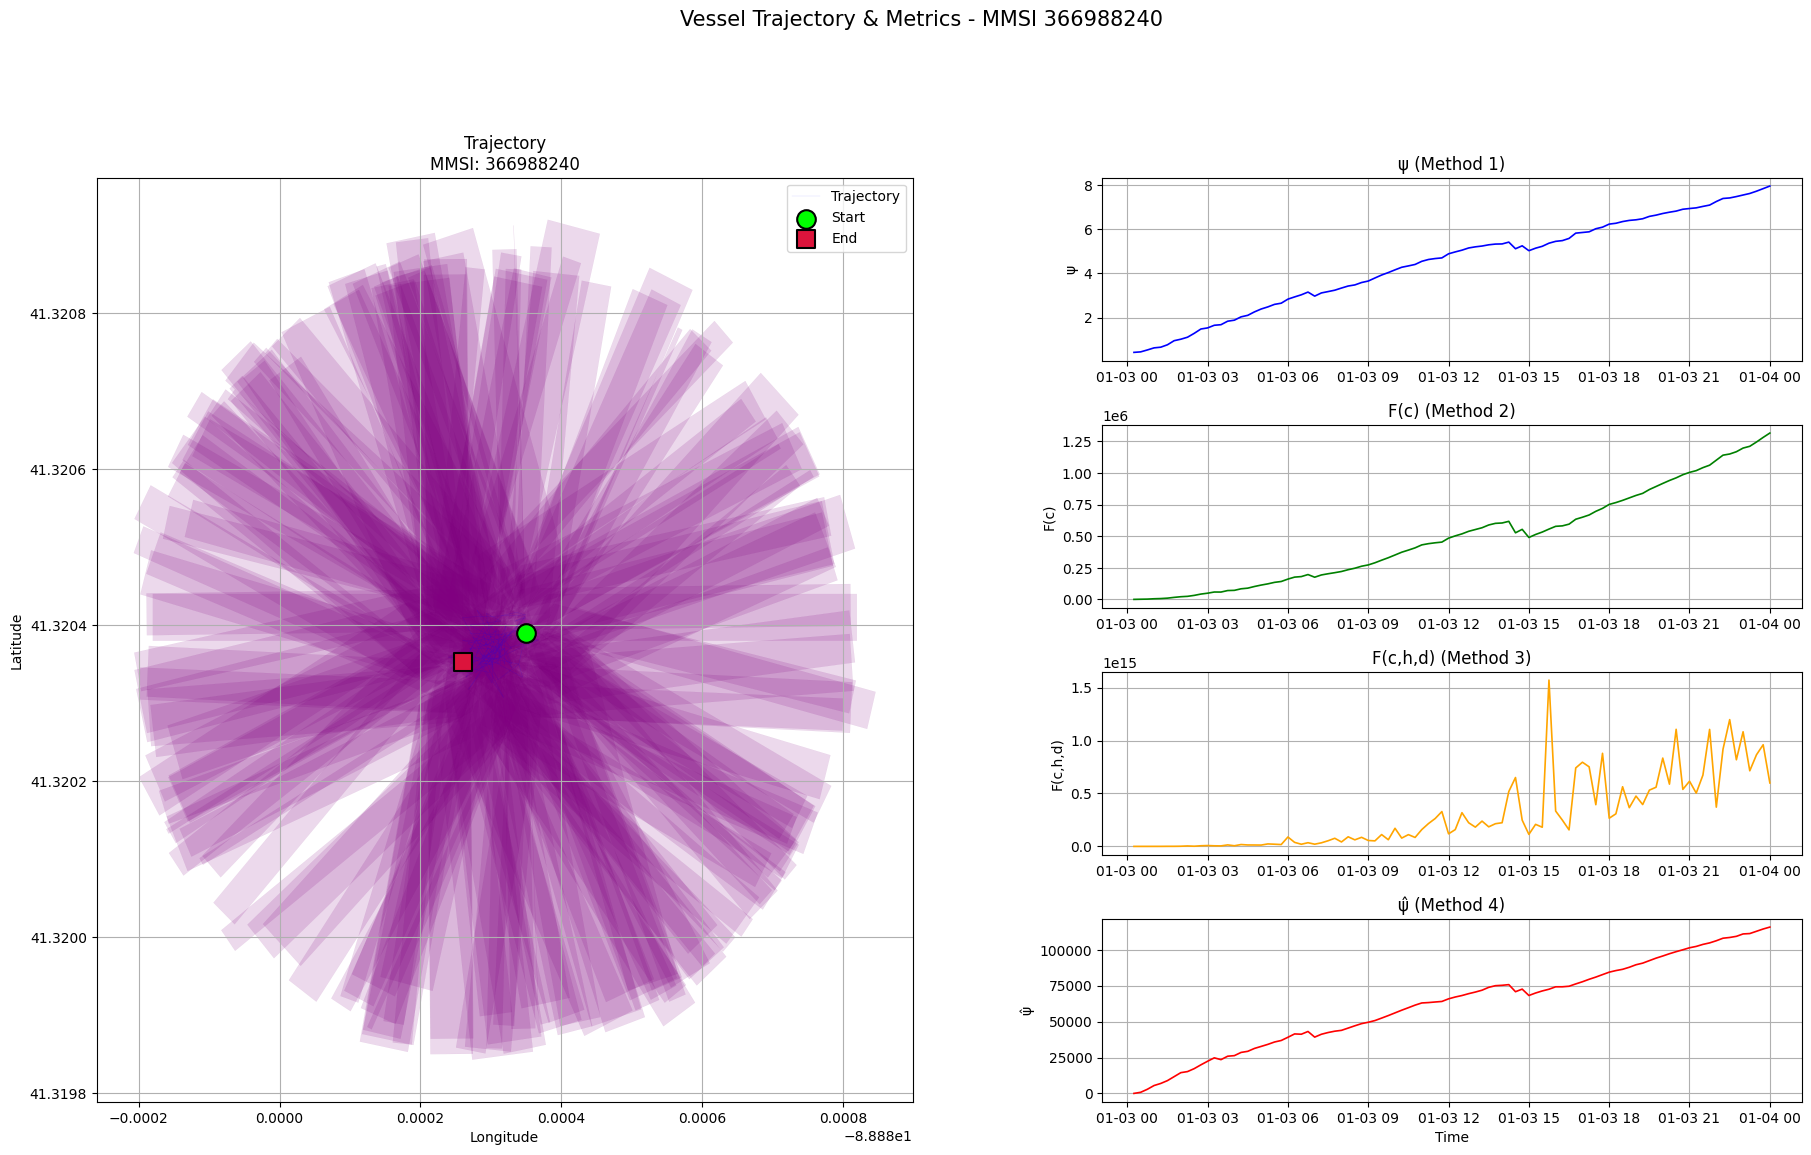

In [6]:
# ==================== VISUALIZE TOP LOITERING VESSELS WITH SMALLER ARROWS AND HORIZONTAL METRIC PLOTS ====================


def plot_vessel_trajectory_and_metrics(
    mmsi, traj_df, m1_psi, m2_Fc, m3_Fchd, m4_psi_hat, figsize=(22, 12)
):
    """
    For a vessel, plot:
      - Left: Trajectory with very small arrows connecting AIS points
      - Start/End markers: larger, more visible
      - Red arrow: reduced opacity, color changed to purple (signifies direction)
      - Right: 4 horizontal time series plots (ψ, F(c), F(c,h,d), ψ̂)
    """
    if len(traj_df) < 2:
        return
    # Prepare time axis
    if "timestamp" in traj_df.columns:
        time_axis = pd.to_datetime(traj_df["timestamp"])
    else:
        time_axis = np.arange(len(traj_df))
    lat = traj_df["lat"].values
    lon = traj_df["lon"].values
    from matplotlib.gridspec import GridSpec

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(4, 2, width_ratios=[3.5, 3], wspace=0.25, hspace=0.35)
    # --- Trajectory with very small arrows (left, spans all rows) ---
    ax_traj = fig.add_subplot(gs[:, 0])
    ax_traj.plot(lon, lat, "b-", linewidth=0.2, alpha=0.25, label="Trajectory")
    # Small arrows connecting each AIS point
    for i in range(1, len(lat)):
        dx = lon[i] - lon[i - 1]
        dy = lat[i] - lat[i - 1]
        ax_traj.arrow(
            lon[i - 1],
            lat[i - 1],
            dx,
            dy,
            head_width=0.00012,
            head_length=0.00009,
            fc="purple",
            ec="purple",
            alpha=0.15,
            length_includes_head=True,
            linewidth=0.1,
        )
    # Start and end points: larger, more visible
    ax_traj.scatter(
        [lon[0]],
        [lat[0]],
        color="lime",
        s=180,
        marker="o",
        label="Start",
        zorder=5,
        edgecolor="black",
        linewidths=1.5,
    )
    ax_traj.scatter(
        [lon[-1]],
        [lat[-1]],
        color="crimson",
        s=180,
        marker="s",
        label="End",
        zorder=5,
        edgecolor="black",
        linewidths=1.5,
    )
    ax_traj.set_xlabel("Longitude")
    ax_traj.set_ylabel("Latitude")
    ax_traj.set_title(f"Trajectory\nMMSI: {mmsi}")
    ax_traj.legend(fontsize=10)
    ax_traj.grid(True)
    # --- Metric 1: ψ (Method 1) ---
    ax1 = fig.add_subplot(gs[0, 1])
    psi_series = [
        method1_trajectory_redundancy(traj_df.iloc[:i])[0]
        for i in range(2, len(traj_df) + 1)
    ]
    ax1.plot(time_axis[1:], psi_series, color="blue", lw=1.2)
    ax1.set_title("ψ (Method 1)")
    ax1.set_ylabel("ψ")
    ax1.grid(True)
    # --- Metric 2: F(c) (Method 2) ---
    ax2 = fig.add_subplot(gs[1, 1])
    Fc_series = [
        method2_loitering_score_Fc(traj_df.iloc[:i])[0]
        for i in range(2, len(traj_df) + 1)
    ]
    ax2.plot(time_axis[1:], Fc_series, color="green", lw=1.2)
    ax2.set_title("F(c) (Method 2)")
    ax2.set_ylabel("F(c)")
    ax2.grid(True)
    # --- Metric 3: F(c,h,d) (Method 3) ---
    ax3 = fig.add_subplot(gs[2, 1])
    Fchd_series = [
        method3_extended_detection_parameter_Fchd(traj_df.iloc[:i])[0]
        for i in range(2, len(traj_df) + 1)
    ]
    ax3.plot(time_axis[1:], Fchd_series, color="orange", lw=1.2)
    ax3.set_title("F(c,h,d) (Method 3)")
    ax3.set_ylabel("F(c,h,d)")
    ax3.grid(True)
    # --- Metric 4: ψ̂ (Method 4) ---
    ax4 = fig.add_subplot(gs[3, 1])
    psi_hat_series = [
        method4_integrated_redundancy_psi_hat(traj_df.iloc[:i])[0]
        for i in range(2, len(traj_df) + 1)
    ]
    ax4.plot(time_axis[1:], psi_hat_series, color="red", lw=1.2)
    ax4.set_title("ψ̂ (Method 4)")
    ax4.set_ylabel("ψ̂")
    ax4.set_xlabel("Time")
    ax4.grid(True)
    plt.suptitle(f"Vessel Trajectory & Metrics - MMSI {mmsi}", fontsize=15, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


print("\n" + "=" * 90)
print(
    "VISUALIZING TOP 15 LOITERING VESSELS WITH SMALLER ARROWS AND HORIZONTAL METRIC PLOTS"
)
print("=" * 90 + "\n")

top_vessels = results_df.nlargest(15, "method1_psi")
for idx, (_, row) in enumerate(top_vessels.iterrows(), 1):
    mmsi = int(row["MMSI"])
    if mmsi in interpolated_data:
        traj = interpolated_data[mmsi]
        print(f"\nVessel {idx}/15: MMSI {mmsi}")
        print(f"  ψ (Method 1): {row['method1_psi']:.6f}")
        print(f"  F(c) (Method 2): {row['method2_Fc']:.6e}")
        print(f"  F(c,h,d) (Method 3): {row['method3_Fchd']:.6e}")
        print(f"  ψ̂ (Method 4): {row['method4_psi_hat']:.6f}")
        plot_vessel_trajectory_and_metrics(
            mmsi,
            traj,
            row["method1_psi"],
            row["method2_Fc"],
            row["method3_Fchd"],
            row["method4_psi_hat"],
        )